# Process Mining Project: BPI Challenge 2020

## Request for Payment Event Log

This project analyses the **BPI Challenge 2020: Request for Payment** event log with **PM4Py**.

The goals are to understand how the process is actually executed, check the quality of the data, find common and unusual paths, measure completion times, and identify possible improvements. An LLM will later help interpret the results produced by PM4Py.

Official source: [BPI Challenge 2020: Request for Payment](https://research.tue.nl/en/datasets/bpi-challenge-2020-request-for-payment/)

## 1. What Is Process Mining?

**Process mining** is a discipline that uses event data recorded by information systems to understand how a process is actually executed.

Traditional process models often describe how a process is expected to work. Process mining starts from the recorded events and reconstructs the paths that were really followed. It can therefore reveal frequent behaviour, exceptional paths, repeated work and points where time accumulates.

The minimum information normally required is:

- a **case identifier**, which identifies one process instance;
- an **activity**, which states what happened;
- a **timestamp**, which states when it happened.

The same approach can be used for payment requests, hospital treatments, insurance claims, orders, support tickets and many other processes.

## 2. Three Core Areas of Process Mining

| Area | Main question | Role in this project |
|---|---|---|
| **Process discovery** | What process model can be learned from the event log? | DFGs and Petri nets are discovered from the recorded payment requests. |
| **Conformance checking** | Does the observed behaviour conform to an existing reference model? | A complete conformance check is not performed because no official reference model is supplied. The discovered models are nevertheless evaluated against the log. |
| **Process enhancement** | How can the process or its model be improved using event data? | Waiting times, rework and incomplete cases are analysed to formulate preliminary improvement suggestions. |

This distinction is important: evaluating a discovered model is not exactly the same as comparing the log with an official *as-designed* process model.

## 3. Practical Workflow and Project Scope

Process mining tools automate many calculations, but the analysis is not completely automatic.

| Phase | What is done | Automated or interpretative? |
|---|---|---|
| 1. Define the objective | Decide which process and questions to study | Analyst decision |
| 2. Build the event log | Identify cases, activities and timestamps | Extraction supported by software |
| 3. Check and prepare data | Inspect missing values, duplicates, incomplete cases and time coverage | Calculations automated; decisions interpreted |
| 4. Explore behaviour | Study activities, trace lengths, outcomes and variants | Mostly automated |
| 5. Discover the process | Generate DFGs and Petri nets | Automated by mining algorithms |
| 6. Evaluate models | Measure fitness, precision, generalization and simplicity | Automated metrics; human comparison |
| 7. Analyse performance | Measure throughput and waiting times | Automated calculations; human interpretation |
| 8. Suggest improvements | Connect evidence to possible actions | Analyst and domain-expert judgment |

This notebook focuses on **process discovery**, **model-quality evaluation** and **performance analysis**. The LLM receives only an aggregated summary and supports the interpretation of results; it does not calculate the metrics or validate business decisions.

## 4. Dataset Origin and Context

The dataset was published for the **Business Process Intelligence Challenge 2020** and contains real events from administrative processes at Eindhoven University of Technology (TU/e).

The complete collection includes several processes connected with travel and expenses. This project uses only the **Request for Payment** log. It records requests for payments such as representation costs or hardware purchases. These requests are normally not part of the travel-expense process, although the documentation says that some travel-related requests appear in this log.

The data are anonymized: people cannot be identified and monetary values are approximate. The log contains **6,886 cases** and **36,796 events**.

## 5. What Is an Event Log?

An **event log** is a dataset that records what happened while a process was running.

Each row is one **event**. Events with the same case identifier belong to the same **case**. When the events of a case are ordered by time, they form its **trace**, meaning the path followed by that request.

The three essential columns are:

- `case:concept:name`: the request identifier;
- `concept:name`: the activity performed;
- `time:timestamp`: when the activity occurred.

Other columns give extra information, such as roles, resources, projects and requested amounts.

## 6. Imports and Environment Verification

We import the libraries used in the notebook and print their versions. This makes it easier to reproduce the analysis.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import pm4py
import matplotlib
import seaborn as sns

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("PM4Py version:", pm4py.__version__)
print("Pandas version:", pd.__version__)



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Python executable: C:\Users\readytouse\PyCharmMiscProject\.venv\Scripts\python.exe
Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
PM4Py version: 2.7.23.8
Pandas version: 3.0.5


## 7. Event Log Path

The original compressed XES file is stored in `data/raw`. We keep it unchanged so that every processing step remains reproducible.

In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent]

project_root = next(
    (
        root
        for root in candidate_roots
        if (root / "data" / "raw" / "RequestForPayment.xes.gz").exists()
    ),
    Path.cwd()
)

log_path = project_root / "data" / "raw" / "RequestForPayment.xes.gz"
images_directory = project_root / "images"
results_directory = project_root / "results"

images_directory.mkdir(parents=True, exist_ok=True)
results_directory.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root.resolve())
print("File path:", log_path.resolve())
print("File exists:", log_path.exists())

Project root: D:\BPI-Challenge-2020
File path: D:\BPI-Challenge-2020\data\raw\RequestForPayment.xes.gz
File exists: True


## 8. Event Log Loading

XES is a standard format for event logs. PM4Py can read the compressed `.xes.gz` file directly and load it as a pandas DataFrame.

In [3]:
log = pm4py.read_xes(str(log_path))

C:\Users\readytouse\PyCharmMiscProject\.venv\Lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


## 9. Initial Dataset Structure

We first inspect the size, columns and first rows of the dataset. One row is one event, so the number of rows is the number of events, not the number of payment requests.

In [4]:
print("Object type:", type(log))
print("Number of rows/events:", log.shape[0])
print("Number of columns:", log.shape[1])

log.head()

Object type: <class 'pandas.DataFrame'>
Number of rows/events: 36796
Number of columns: 14


,case:Activity,case:concept:name,id,case:Cost Type,case:RfpNumber,org:role,case:OrganizationalEntity,org:resource,time:timestamp,case:Rfp_id,case:Task,concept:name,case:RequestedAmount,case:Project
0,UNKNOWN,request for payment 148214,st_step 148220_0,0,request for payment number 148215,EMPLOYEE,organizational unit 65463,STAFF MEMBER,2017-01-09 08:17:18+00:00,request for payment 148214,UNKNOWN,Request For Payment SUBMITTED by EMPLOYEE,34.336343,project 148216
1,UNKNOWN,request for payment 148214,st_step 148221_0,0,request for payment number 148215,SUPERVISOR,organizational unit 65463,STAFF MEMBER,2017-01-09 08:18:00+00:00,request for payment 148214,UNKNOWN,Request For Payment FINAL_APPROVED by SUPERVISOR,34.336343,project 148216
2,UNKNOWN,request for payment 148214,st_step 148222_0,0,request for payment number 148215,MISSING,organizational unit 65463,STAFF MEMBER,2017-01-10 11:42:32+00:00,request for payment 148214,UNKNOWN,Request For Payment REJECTED by MISSING,34.336343,project 148216
3,UNKNOWN,request for payment 148214,st_step 148219_0,0,request for payment number 148215,EMPLOYEE,organizational unit 65463,STAFF MEMBER,2017-03-03 08:51:13+00:00,request for payment 148214,UNKNOWN,Request For Payment SUBMITTED by EMPLOYEE,34.336343,project 148216
4,UNKNOWN,request for payment 148214,st_step 148218_0,0,request for payment number 148215,PRE_APPROVER,organizational unit 65463,STAFF MEMBER,2017-03-03 08:51:42+00:00,request for payment 148214,UNKNOWN,Request For Payment APPROVED by PRE_APPROVER,34.336343,project 148216


### 9.1 Column Names

In [5]:
print("Column names:")
for column in log.columns:
    print("-", column)

Column names:
- case:Activity
- case:concept:name
- id
- case:Cost Type
- case:RfpNumber
- org:role
- case:OrganizationalEntity
- org:resource
- time:timestamp
- case:Rfp_id
- case:Task
- concept:name
- case:RequestedAmount
- case:Project


### 9.2 Column Structure

For each column, the table shows its data type, present values, missing values and distinct values.

A missing value is not always an error: some information may be relevant only to particular activities.

In [6]:
structure = pd.DataFrame({
    "data_type": log.dtypes.astype(str),
    "non_null_values": log.notna().sum(),
    "missing_values": log.isna().sum(),
    "missing_percentage": log.isna().mean().mul(100).round(2),
    "unique_values": log.nunique(dropna=True)
})

structure

,data_type,non_null_values,missing_values,missing_percentage,unique_values
case:Activity,str,36796,0,0.0,6
case:concept:name,str,36796,0,0.0,6886
id,str,36796,0,0.0,36796
case:Cost Type,int64,36796,0,0.0,1
case:RfpNumber,str,36796,0,0.0,6322
org:role,str,36796,0,0.0,8
case:OrganizationalEntity,str,36796,0,0.0,36
org:resource,str,36796,0,0.0,2
time:timestamp,"datetime64[us, UTC]",36796,0,0.0,30141
case:Rfp_id,str,36796,0,0.0,6886


### 9.3 Essential Event Log Columns

This view shows the case identifier, activity and timestamp. A case identifier appears several times because one request normally contains several events.

In [7]:
essential_columns = [
    "case:concept:name",
    "concept:name",
    "time:timestamp"
]

log[essential_columns].head(10)

,case:concept:name,concept:name,time:timestamp
0,request for payment 148214,Request For Payment SUBMITTED by EMPLOYEE,2017-01-09 08:17:18+00:00
1,request for payment 148214,Request For Payment FINAL_APPROVED by SUPERVISOR,2017-01-09 08:18:00+00:00
2,request for payment 148214,Request For Payment REJECTED by MISSING,2017-01-10 11:42:32+00:00
3,request for payment 148214,Request For Payment SUBMITTED by EMPLOYEE,2017-03-03 08:51:13+00:00
4,request for payment 148214,Request For Payment APPROVED by PRE_APPROVER,2017-03-03 08:51:42+00:00
5,request for payment 148214,Request For Payment FINAL_APPROVED by SUPERVISOR,2017-03-06 07:55:50+00:00
6,request for payment 148214,Request Payment,2017-03-08 10:22:42+00:00
7,request for payment 148214,Payment Handled,2017-03-16 16:31:12+00:00
8,request for payment 149290,Request For Payment SUBMITTED by EMPLOYEE,2017-01-09 09:30:48+00:00
9,request for payment 149290,Request For Payment FINAL_APPROVED by SUPERVISOR,2017-01-09 09:31:42+00:00


## 10. Activity Distribution

The activity distribution counts how many times each action appears in the log. It helps us see which actions are common and which are rare.

Different frequencies are not automatically a problem. For example, every completed request may contain a payment activity, while an exceptional approval may occur only in a few cases.

In [8]:
activity_distribution = (
    log["concept:name"]
    .value_counts()
    .rename_axis("activity")
    .reset_index(name="number_of_events")
)

activity_distribution["percentage"] = (
    activity_distribution["number_of_events"]
    / len(log)
    * 100
).round(2)

activity_distribution

,activity,number_of_events,percentage
0,Request For Payment SUBMITTED by EMPLOYEE,7504,20.39
1,Request For Payment FINAL_APPROVED by SUPERVISOR,6343,17.24
2,Payment Handled,6307,17.14
3,Request Payment,6303,17.13
4,Request For Payment APPROVED by ADMINISTRATION,5489,14.92
5,Request For Payment APPROVED by BUDGET OWNER,2014,5.47
6,Request For Payment REJECTED by EMPLOYEE,1085,2.95
7,Request For Payment REJECTED by ADMINISTRATION,836,2.27
8,Request For Payment APPROVED by PRE_APPROVER,413,1.12
9,Request For Payment REJECTED by SUPERVISOR,179,0.49


We also count the number of distinct payment requests, that is, the number of cases.

In [9]:
log["case:concept:name"].nunique()

6886

The log contains **19 activity types** and **6,886 payment requests**.

`SUBMITTED by EMPLOYEE` appears 7,504 times, which is more than the number of cases. This suggests that some requests were submitted more than once. To understand why, we must inspect the order of activities inside each case.

## 11. Cases and Trace Length

A **case** is one payment request. Its **trace length** is the number of recorded events for that request.

Different trace lengths show that requests do not all follow exactly the same path. Long traces may include rejections and repeated submissions; short traces may be unfinished or exceptional.

In [10]:
case_id_column = "case:concept:name"

number_of_cases = log[case_id_column].nunique()
number_of_events = len(log)

events_per_case = log.groupby(case_id_column).size()

print("Number of cases:", number_of_cases)
print("Number of events:", number_of_events)
print("Minimum events per case:", events_per_case.min())
print("Maximum events per case:", events_per_case.max())
print("Average events per case:", round(events_per_case.mean(), 2))
print("Median events per case:", events_per_case.median())

Number of cases: 6886
Number of events: 36796
Minimum events per case: 1
Maximum events per case: 20
Average events per case: 5.34
Median events per case: 5.0


The log contains:

- **6,886 cases**: distinct requests for payment;
- **36,796 events**: all actions recorded for those requests;
- a minimum of **1 event** and a maximum of **20 events** per case;
- an average of **5.34 events** per case and a median of **5 events**.

We will inspect the very short and very long cases before deciding what they mean.

## 12. Trace Length Distribution

This distribution counts how many cases have 1 event, 2 events, 3 events, and so on. It shows the usual size of a case and makes unusual lengths easier to identify.

In [11]:
trace_length_distribution = (
    events_per_case
    .value_counts()
    .sort_index()
    .rename_axis("trace_length")
    .reset_index(name="number_of_cases")
)

trace_length_distribution["percentage_of_cases"] = (
    trace_length_distribution["number_of_cases"]
    / number_of_cases
    * 100
).round(2)

trace_length_distribution

,trace_length,number_of_cases,percentage_of_cases
0,1,72,1.05
1,2,8,0.12
2,3,394,5.72
3,4,644,9.35
4,5,3375,49.01
5,6,1804,26.20
6,7,49,0.71
7,8,233,3.38
8,9,173,2.51
9,10,63,0.91


The same result is shown in a chart.

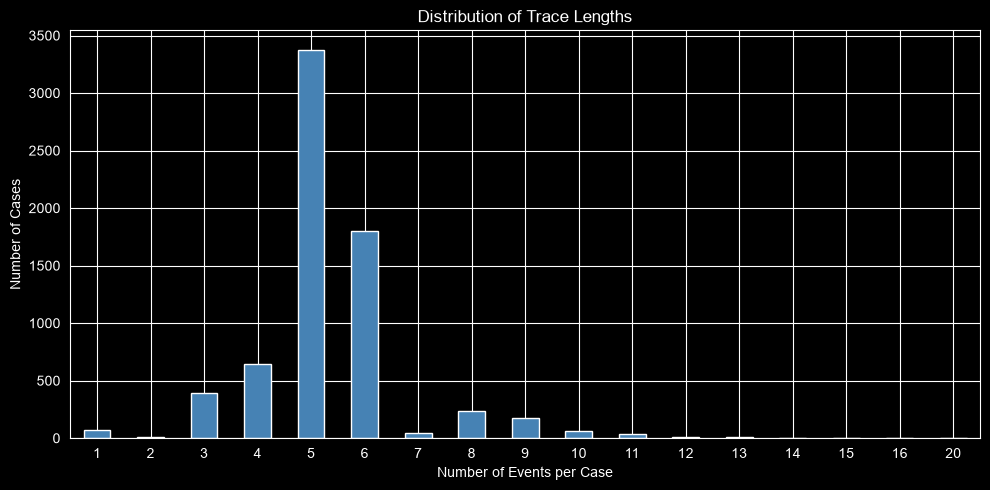

In [12]:
import matplotlib.pyplot as plt

ax = trace_length_distribution.plot(
    kind="bar",
    x="trace_length",
    y="number_of_cases",
    figsize=(10, 5),
    color="steelblue",
    legend=False
)

ax.set_title("Distribution of Trace Lengths")
ax.set_xlabel("Number of Events per Case")
ax.set_ylabel("Number of Cases")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Most requests have a similar length:

- 3,375 cases (49.01%) contain 5 events;
- 1,804 cases (26.20%) contain 6 events;
- together, cases with 5 or 6 events represent 75.21% of the log;
- cases with 3 to 6 events represent 90.28% of the log.

**Conclusion:** most requests follow a path containing five or six recorded activities.

## 13. Inspection of Short and Long Traces

A short or long trace is not automatically wrong. We inspect its activity sequence to understand whether it represents an unfinished request, a rejection, a correction or repeated work.

In [13]:
short_case_ids = events_per_case[
    events_per_case == events_per_case.min()
].index

short_cases = log[
    log[case_id_column].isin(short_case_ids)
]

short_case_activities = (
    short_cases["concept:name"]
    .value_counts()
    .rename_axis("activity")
    .reset_index(name="number_of_cases")
)

short_case_activities

,activity,number_of_cases
0,Request For Payment SAVED by EMPLOYEE,72


All 72 one-event cases contain only `Request For Payment SAVED by EMPLOYEE`.

They probably represent requests saved as drafts and never submitted.

In [14]:
longest_case_id = events_per_case.idxmax()
longest_case_length = events_per_case.max()

print("Longest case ID:", longest_case_id)
print("Number of events:", longest_case_length)

longest_trace = (
    log[log[case_id_column] == longest_case_id]
    .sort_values("time:timestamp")
    [
        [
            "case:concept:name",
            "time:timestamp",
            "concept:name",
            "org:role",
            "org:resource"
        ]
    ]
)

longest_trace

Longest case ID: request for payment 171883
Number of events: 20


,case:concept:name,time:timestamp,concept:name,org:role,org:resource
29394,request for payment 171883,2018-10-20 14:48:38+00:00,Request For Payment SUBMITTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER
29395,request for payment 171883,2018-10-20 14:48:42+00:00,Request For Payment REJECTED by ADMINISTRATION,ADMINISTRATION,STAFF MEMBER
29396,request for payment 171883,2018-10-24 06:21:07+00:00,Request For Payment REJECTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER
29397,request for payment 171883,2018-10-25 13:13:10+00:00,Request For Payment SUBMITTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER
29398,request for payment 171883,2018-10-25 13:13:13+00:00,Request For Payment REJECTED by ADMINISTRATION,ADMINISTRATION,STAFF MEMBER
29399,request for payment 171883,2018-10-31 10:33:43+00:00,Request For Payment REJECTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER
29400,request for payment 171883,2018-10-31 10:57:22+00:00,Request For Payment SUBMITTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER
29401,request for payment 171883,2018-10-31 10:57:27+00:00,Request For Payment REJECTED by ADMINISTRATION,ADMINISTRATION,STAFF MEMBER
29402,request for payment 171883,2018-10-31 11:05:45+00:00,Request For Payment REJECTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER
29403,request for payment 171883,2018-10-31 11:22:50+00:00,Request For Payment SUBMITTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER


### Longest Trace: request for payment 171883

This case contains 20 events. The employee submitted the request several times. The administration rejected it, the employee received the rejection, and the cycle started again.

After five rejection cycles, the sixth submission was approved by the administration and the supervisor. The payment was then requested and handled.

This is an example of **rework**, because some activities had to be repeated before the case was completed.

### Conclusion About Extreme Traces

The shortest traces appear to be saved drafts. The longest trace contains repeated rejections and submissions before final payment.

The activity sequence shows what happened, but it does not explain why the request was rejected.

## 14. Process Variant Analysis

A **process variant** is one distinct sequence of activities. Cases belong to the same variant when they contain the same activities in the same order.

For example, `Submit → Approve → Pay` and `Submit → Reject → Submit → Approve → Pay` are two different variants.

Variant analysis shows the common paths and the less frequent paths followed by requests.

In [15]:
ordered_log = log.sort_values(
    by=[case_id_column, "time:timestamp"],
    kind="stable"
)

case_variants = (
    ordered_log
    .groupby(case_id_column)["concept:name"]
    .agg(tuple)
)

number_of_variants = case_variants.nunique()

variant_distribution = (
    case_variants
    .value_counts()
    .rename_axis("variant")
    .reset_index(name="number_of_cases")
)

variant_distribution["percentage_of_cases"] = (
    variant_distribution["number_of_cases"]
    / number_of_cases
    * 100
).round(2)

variant_distribution["cumulative_percentage"] = (
    variant_distribution["number_of_cases"]
    .cumsum()
    .div(number_of_cases)
    .mul(100)
    .round(2)
)

variant_distribution.insert(
    0,
    "variant_id",
    ["V" + str(i) for i in range(1, len(variant_distribution) + 1)]
)

variant_distribution["activity_sequence"] = (
    variant_distribution["variant"]
    .apply(lambda sequence: " → ".join(sequence))
)

print("Number of distinct variants:", number_of_variants)

variant_distribution[
    [
        "variant_id",
        "number_of_cases",
        "percentage_of_cases",
        "cumulative_percentage",
        "activity_sequence"
    ]
].head(10)

Number of distinct variants: 89


,variant_id,number_of_cases,percentage_of_cases,cumulative_percentage,activity_sequence
0,V1,3011,43.73,43.73,Request For Payment SUBMITTED by EMPLOYEE → Re...
1,V2,1762,25.59,69.31,Request For Payment SUBMITTED by EMPLOYEE → Re...
2,V3,583,8.47,77.78,Request For Payment SUBMITTED by EMPLOYEE → Re...
3,V4,343,4.98,82.76,Request For Payment SUBMITTED by EMPLOYEE → Re...
4,V5,340,4.94,87.70,Request For Payment SUBMITTED by EMPLOYEE → Re...
5,V6,202,2.93,90.63,Request For Payment SUBMITTED by EMPLOYEE → Re...
6,V7,115,1.67,92.30,Request For Payment SUBMITTED by EMPLOYEE → Re...
7,V8,72,1.05,93.35,Request For Payment SAVED by EMPLOYEE
8,V9,39,0.57,93.92,Request For Payment SUBMITTED by EMPLOYEE → Re...
9,V10,28,0.41,94.32,Request For Payment SUBMITTED by EMPLOYEE → Re...


### Reading the Most Frequent Variants

- **V1** is the most common path and contains 3,011 cases (43.73%). It is a successful path without rejections.
- **V2** is similar to V1 but also includes approval by the budget owner.
- **V3** reaches final approval without the administration or budget-owner approval activities shown in V1 and V2.
- **V4** contains requests rejected without a later payment.
- **V5** includes approval by a pre-approver.
- **V6, V7, V9 and V10** contain rejection, resubmission and eventual payment.
- **V8** contains the 72 requests saved as drafts and never submitted.

The first three variants cover 77.78% of all cases.

### Conclusion About Variants

A few paths describe most requests, while many other paths are uncommon. This is an **imbalanced variant distribution**.

Imbalance does not mean that the data are wrong. Rare paths may be valid exceptions, rework or unfinished cases.

## 15. Common and Rare Variants

We now measure how many cases follow the most common variants and how many belong to rare variants. Here, a rare variant is followed by at most five cases.

In [16]:
total_variants = len(variant_distribution)

single_case_variants = (
    variant_distribution["number_of_cases"] == 1
).sum()

rare_variants = (
    variant_distribution["number_of_cases"] <= 5
).sum()

cases_in_rare_variants = variant_distribution.loc[
    variant_distribution["number_of_cases"] <= 5,
    "number_of_cases"
].sum()

print("Total number of variants:", total_variants)
print("Variants followed by only one case:", single_case_variants)
print("Variants followed by at most five cases:", rare_variants)
print("Cases belonging to rare variants:", cases_in_rare_variants)
print(
    "Percentage of cases in rare variants:",
    round(cases_in_rare_variants / number_of_cases * 100, 2),
    "%"
)
print(
    "Cases covered by the top 10 variants:",
    variant_distribution.head(10)["number_of_cases"].sum()
)

Total number of variants: 89
Variants followed by only one case: 41
Variants followed by at most five cases: 57
Cases belonging to rare variants: 82
Percentage of cases in rare variants: 1.19 %
Cases covered by the top 10 variants: 6495


### Interpretation

The log contains **89 variants**. Of these, 57 variants are followed by at most five cases, but together they contain only 82 cases (1.19% of all requests).

The ten most common variants contain 6,495 cases (94.32%). Therefore, most requests follow a small number of common paths, while many rare paths contain very few cases.

## 16. End Activity Distribution

The end activity is the last event recorded for a case. It gives an initial idea of whether the request was paid, rejected, saved or left at an intermediate step.

In [17]:
end_events = (
    ordered_log
    .groupby(case_id_column, sort=False)
    .tail(1)
)

end_activity_distribution = (
    end_events["concept:name"]
    .value_counts()
    .rename_axis("end_activity")
    .reset_index(name="number_of_cases")
)

end_activity_distribution["percentage_of_cases"] = (
    end_activity_distribution["number_of_cases"]
    / number_of_cases
    * 100
).round(2)

end_activity_distribution

,end_activity,number_of_cases,percentage_of_cases
0,Payment Handled,6305,91.56
1,Request For Payment REJECTED by EMPLOYEE,448,6.51
2,Request For Payment SAVED by EMPLOYEE,74,1.07
3,Request For Payment REJECTED by MISSING,41,0.60
4,Request For Payment FINAL_APPROVED by SUPERVISOR,11,0.16
5,Request For Payment REJECTED by ADMINISTRATION,2,0.03
6,Request Payment,2,0.03
7,Request For Payment FINAL_APPROVED by DIRECTOR,1,0.01
8,Request For Payment FOR_APPROVAL by SUPERVISOR,1,0.01
9,Request For Payment REJECTED by SUPERVISOR,1,0.01


### Interpretation of End Activities

- 6,305 cases (91.56%) end with `Payment Handled`;
- 492 cases (7.14%) end with a rejection;
- 74 cases (1.07%) end with `SAVED by EMPLOYEE`;
- 15 cases (0.22%) end at another activity.

Most cases therefore end with a completed payment. Cases ending at another step are not automatically errors; some may be rejected, saved or still incomplete when the data were extracted.

## 17. Case Outcome Classification

For a simpler summary, we group cases according to their last activity: **Completed**, **Rejected**, **Saved**, or **Incomplete or other**.

This is only a descriptive grouping. We are not training a machine-learning classifier.

In [18]:
def classify_case_outcome(end_activity):
    if end_activity == "Payment Handled":
        return "Completed"

    if "REJECTED" in end_activity:
        return "Rejected"

    if "SAVED" in end_activity:
        return "Saved"

    return "Incomplete or other"


case_outcomes = end_events[
    [case_id_column, "concept:name"]
].copy()

case_outcomes["outcome"] = (
    case_outcomes["concept:name"]
    .apply(classify_case_outcome)
)

outcome_distribution = (
    case_outcomes["outcome"]
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="number_of_cases")
)

outcome_distribution["percentage_of_cases"] = (
    outcome_distribution["number_of_cases"]
    / number_of_cases
    * 100
).round(2)

outcome_distribution

,outcome,number_of_cases,percentage_of_cases
0,Completed,6305,91.56
1,Rejected,492,7.14
2,Saved,74,1.07
3,Incomplete or other,15,0.22


### Interpretation of Case Outcomes

We classify a case from its **last recorded activity**. A request rejected earlier but later corrected and paid is therefore counted as completed.

The results are:

- Completed: 6,305 cases (91.56%);
- Rejected: 492 cases (7.14%);
- Saved: 74 cases (1.07%);
- Incomplete or other: 15 cases (0.22%).

The rejection percentage is calculated as `492 / 6886 × 100 = 7.14%`.

The outcomes are strongly concentrated on completed payments. This describes the real process; it is not by itself a data-quality problem.

## 18. Data Quality Assessment

Before analysing performance, we check whether the essential information is usable. We look for missing case identifiers, activities or timestamps, invalid dates, duplicate events and very short or unfinished cases.

An unfinished case is not automatically an error, so the original log is kept unchanged.

In [19]:
timestamp_column = "time:timestamp"

parsed_timestamps = pd.to_datetime(
    log[timestamp_column],
    errors="coerce",
    utc=True
)

duplicate_event_ids = (
    log["id"].duplicated().sum()
    if "id" in log.columns
    else pd.NA
)

data_quality_checks = pd.DataFrame({
    "quality_check": [
        "Missing case identifiers",
        "Missing activity names",
        "Missing timestamps",
        "Unparseable timestamps",
        "Exact duplicated rows",
        "Duplicated event identifiers",
        "Cases containing only one event",
        "Cases not ending with Payment Handled"
    ],
    "value": [
        log[case_id_column].isna().sum(),
        log["concept:name"].isna().sum(),
        log[timestamp_column].isna().sum(),
        parsed_timestamps.isna().sum(),
        log.duplicated().sum(),
        duplicate_event_ids,
        (events_per_case == 1).sum(),
        number_of_cases - (
            end_events["concept:name"] == "Payment Handled"
        ).sum()
    ]
})

data_quality_checks

,quality_check,value
0,Missing case identifiers,0
1,Missing activity names,0
2,Missing timestamps,0
3,Unparseable timestamps,0
4,Exact duplicated rows,0
5,Duplicated event identifiers,0
6,Cases containing only one event,72
7,Cases not ending with Payment Handled,581


In [20]:
print("First recorded event:", parsed_timestamps.min())
print("Last recorded event:", parsed_timestamps.max())

First recorded event: 2017-01-09 08:17:18+00:00
Last recorded event: 2019-08-08 12:57:18+00:00


### Interpretation of Data Quality

The essential data are technically complete: there are no missing case identifiers, activity names or timestamps, no invalid timestamps, and no duplicate rows or event identifiers.

The 72 one-event cases and the 581 cases not ending with `Payment Handled` are still useful. They describe saved, rejected or incomplete requests rather than corrupted data.

### 18.1 Preprocessing Decision

Preprocessing may include cleaning, filtering or generating additional cases, but each operation must be justified by the characteristics of the event log.

In this project, the original event log was preserved because:

- the essential case identifiers, activity names and timestamps were complete;
- no exact duplicated rows were found;
- the dataset already contains **6,886 real process instances**, so synthetic cases were not necessary.

Filtering was used only to create analytical subsets and clearer visual representations. These operations did not alter the original event log, and the three process models were evaluated on the complete log.

**Conclusion:** preprocessing prepared the data for analysis without rewriting the behaviour recorded in the official BPI Challenge 2020 dataset.

## 19. Temporal Coverage

The dataset concerns requests started in 2017 and 2018, but some recorded events occur in 2019. We check whether these are new 2019 cases or later events of older cases before deciding whether to keep them.

In [21]:
temporal_log = log.copy()
temporal_log["event_year"] = parsed_timestamps.dt.year

year_distribution = (
    temporal_log
    .groupby("event_year")
    .agg(
        number_of_events=("concept:name", "size"),
        number_of_cases=(case_id_column, "nunique")
    )
    .reset_index()
)

year_distribution["percentage_of_events"] = (
    year_distribution["number_of_events"]
    / number_of_events
    * 100
).round(2)

year_distribution

,event_year,number_of_events,number_of_cases,percentage_of_events
0,2017,4919,1108,13.37
1,2018,31266,5806,84.97
2,2019,611,293,1.66


In [22]:
case_time_bounds = (
    temporal_log
    .groupby(case_id_column)["time:timestamp"]
    .agg(case_start="min", case_end="max")
)

case_time_bounds["start_year"] = (
    case_time_bounds["case_start"].dt.year
)

case_time_bounds["end_year"] = (
    case_time_bounds["case_end"].dt.year
)

case_year_distribution = pd.concat(
    [
        case_time_bounds["start_year"]
        .value_counts()
        .sort_index()
        .rename("cases_started"),

        case_time_bounds["end_year"]
        .value_counts()
        .sort_index()
        .rename("cases_ended")
    ],
    axis=1
).fillna(0).astype(int)

case_year_distribution.index.name = "year"

case_year_distribution

,cases_started,cases_ended
year,,
2017,1108,1080
2018,5778,5513
2019,0,293


### Interpretation of Temporal Coverage

All 6,886 cases start in 2017 or 2018. No new case starts in 2019.

The 2019 events belong to cases that started earlier and finished later. They are kept because removing them would cut off the end of those cases.

## 20. Data Preparation and Analysis Subsets

No corrupted event needs to be removed. Instead, we create separate subsets for different questions:

- the complete log for activities, variants and outcomes;
- completed cases for completion-time analysis;
- rejected cases for unsuccessful paths;
- saved or incomplete cases for unfinished behaviour.

The original log remains unchanged, and the 2019 events are preserved.

In [23]:
completed_case_ids = case_outcomes.loc[
    case_outcomes["outcome"] == "Completed",
    case_id_column
]

rejected_case_ids = case_outcomes.loc[
    case_outcomes["outcome"] == "Rejected",
    case_id_column
]

unfinished_case_ids = case_outcomes.loc[
    case_outcomes["outcome"].isin(
        ["Saved", "Incomplete or other"]
    ),
    case_id_column
]

completed_log = log[
    log[case_id_column].isin(completed_case_ids)
].copy()

rejected_log = log[
    log[case_id_column].isin(rejected_case_ids)
].copy()

unfinished_log = log[
    log[case_id_column].isin(unfinished_case_ids)
].copy()

subset_summary = pd.DataFrame({
    "subset": [
        "Complete original log",
        "Completed cases",
        "Rejected cases",
        "Saved or incomplete cases"
    ],
    "number_of_cases": [
        log[case_id_column].nunique(),
        completed_log[case_id_column].nunique(),
        rejected_log[case_id_column].nunique(),
        unfinished_log[case_id_column].nunique()
    ],
    "number_of_events": [
        len(log),
        len(completed_log),
        len(rejected_log),
        len(unfinished_log)
    ]
})

subset_summary

,subset,number_of_cases,number_of_events
0,Complete original log,6886,36796
1,Completed cases,6305,34996
2,Rejected cases,492,1668
3,Saved or incomplete cases,89,132


### Check of the Subsets

Together, the subsets still contain all **6,886 cases** and **36,796 events**. No data were lost.

Completed cases contain more events on average because they continue through approval and payment. Rejected, saved and incomplete cases usually stop earlier.

## 21. Throughput Time Analysis

The **throughput time** is the time between the first and last event of a case.

Here we analyse only completed cases, whose last event is `Payment Handled`. Rejected or unfinished cases stop at different stages, so their durations are not directly comparable.

In [24]:
completed_log["time:timestamp"] = pd.to_datetime(
    completed_log["time:timestamp"],
    errors="coerce",
    utc=True
)

completed_case_times = (
    completed_log
    .groupby(case_id_column)["time:timestamp"]
    .agg(
        case_start="min",
        case_end="max"
    )
)

completed_case_times["duration"] = (
    completed_case_times["case_end"]
    - completed_case_times["case_start"]
)

completed_case_times["duration_hours"] = (
    completed_case_times["duration"]
    .dt.total_seconds()
    / 3600
)

completed_case_times["duration_days"] = (
    completed_case_times["duration_hours"]
    / 24
)

throughput_summary = (
    completed_case_times["duration_days"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
    .to_frame(name="duration_days")
)

throughput_summary

,duration_days
count,6305.00
mean,12.54
std,15.59
min,1.12
25%,6.21
50%,9.04
75%,14.09
90%,22.13
95%,32.14
99%,70.00


In [25]:
print(
    "Cases with negative duration:",
    (completed_case_times["duration_days"] < 0).sum()
)

print(
    "Cases completed in less than one hour:",
    (completed_case_times["duration_hours"] < 1).sum()
)

print(
    "Cases lasting more than 30 days:",
    (completed_case_times["duration_days"] > 30).sum()
)

Cases with negative duration: 0
Cases completed in less than one hour: 0
Cases lasting more than 30 days: 356


### Interpretation of Throughput Times

A completed request takes **12.54 days on average**. The **median is 9.04 days**, meaning that half of completed requests finish in less than about 9 days and half take longer.

The average is higher because some cases last much longer: 356 cases take more than 30 days, 64 take more than 70 days, and the longest takes about 406 days.

These cases are not automatically errors. We must inspect the time gaps and repeated activities to understand why they lasted so long.

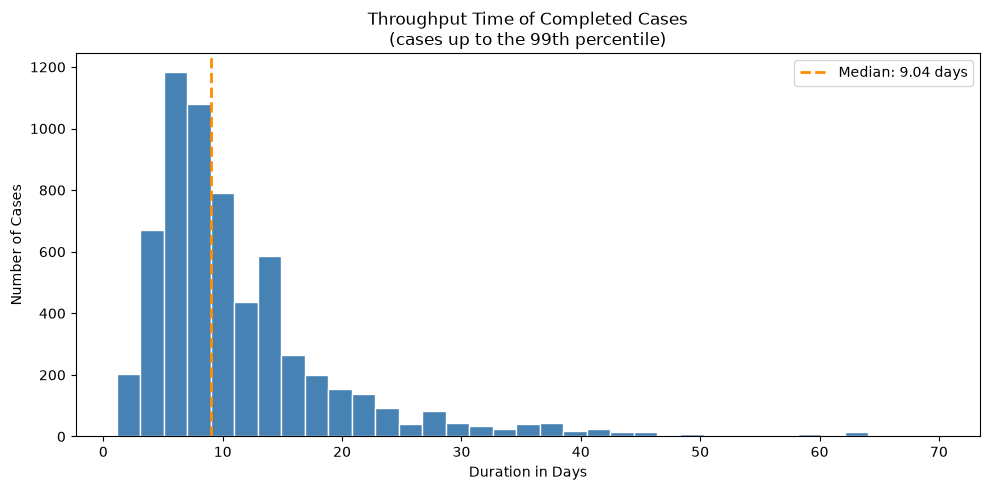

In [26]:
# We exclude the slowest 1% only from the chart
# so that the main distribution remains readable.
percentile_99 = completed_case_times["duration_days"].quantile(0.99)

durations_for_histogram = completed_case_times.loc[
    completed_case_times["duration_days"] <= percentile_99,
    "duration_days"
]

median_duration = completed_case_times["duration_days"].median()

plt.style.use("default")

fig, ax = plt.subplots(
    figsize=(10, 5),
    facecolor="white"
)

ax.hist(
    durations_for_histogram,
    bins=35,
    color="steelblue",
    edgecolor="white"
)

ax.axvline(
    median_duration,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_duration:.2f} days"
)

ax.set_title(
    "Throughput Time of Completed Cases\n"
    "(cases up to the 99th percentile)"
)
ax.set_xlabel("Duration in Days")
ax.set_ylabel("Number of Cases")
ax.legend()

plt.tight_layout()
plt.show()

The following table shows the ten completed cases with the longest duration.

In [27]:
longest_completed_cases = (
    completed_case_times
    .sort_values(
        by="duration_days",
        ascending=False
    )
    .head(10)
)

longest_completed_cases[
    [
        "case_start",
        "case_end",
        "duration_days"
    ]
]

,case_start,case_end,duration_days
case:concept:name,,,
request for payment 159986,2018-03-01 15:41:13+00:00,2019-04-11 15:31:14+00:00,405.993067
request for payment 162246,2018-07-10 06:58:28+00:00,2019-03-21 16:30:59+00:00,254.397581
request for payment 164816,2018-06-07 09:57:29+00:00,2019-02-04 16:31:26+00:00,242.273576
request for payment 164181,2018-03-29 12:03:26+00:00,2018-11-22 16:31:34+00:00,238.186204
request for payment 153217,2018-03-16 14:26:34+00:00,2018-11-01 16:31:17+00:00,230.086609
request for payment 157838,2018-03-16 14:28:42+00:00,2018-11-01 16:31:17+00:00,230.085127
request for payment 147643,2017-05-02 11:32:06+00:00,2017-12-04 16:31:18+00:00,216.207778
request for payment 155039,2018-01-09 16:17:27+00:00,2018-08-06 15:31:07+00:00,208.967824
request for payment 153414,2018-01-31 16:12:37+00:00,2018-08-20 15:31:18+00:00,200.971308


In [28]:
duration_checks = pd.DataFrame({
    "check": [
        "Cases with negative duration",
        "Cases completed in less than one hour",
        "Cases lasting more than 30 days",
        "Cases lasting more than 70 days"
    ],
    "number_of_cases": [
        (completed_case_times["duration_days"] < 0).sum(),
        (completed_case_times["duration_hours"] < 1).sum(),
        (completed_case_times["duration_days"] > 30).sum(),
        (completed_case_times["duration_days"] > 70).sum()
    ]
})

duration_checks

,check,number_of_cases
0,Cases with negative duration,0
1,Cases completed in less than one hour,0
2,Cases lasting more than 30 days,356
3,Cases lasting more than 70 days,64


### Check of Long-Running Cases

No completed case has a throughput time below one hour. Because throughput is calculated as the difference between the maximum and minimum timestamp, the absence of negative durations is expected and is not, by itself, a separate data-quality test.

However, 356 completed cases (5.65%) last more than 30 days, and 64 cases (1.02%) last more than 70 days. These long cases should be examined to locate long gaps or repeated work. Their duration alone does not reveal the organizational cause.

In [29]:
cases_over_70_days = (
    completed_case_times["duration_days"] > 70
).sum()

print("Cases lasting more than 70 days:", cases_over_70_days)

longest_completed_cases = (
    completed_case_times
    .sort_values(
        by="duration_days",
        ascending=False
    )
    .head(10)
)

longest_completed_cases[
    [
        "case_start",
        "case_end",
        "duration_days"
    ]
]

Cases lasting more than 70 days: 64


,case_start,case_end,duration_days
case:concept:name,,,
request for payment 159986,2018-03-01 15:41:13+00:00,2019-04-11 15:31:14+00:00,405.993067
request for payment 162246,2018-07-10 06:58:28+00:00,2019-03-21 16:30:59+00:00,254.397581
request for payment 164816,2018-06-07 09:57:29+00:00,2019-02-04 16:31:26+00:00,242.273576
request for payment 164181,2018-03-29 12:03:26+00:00,2018-11-22 16:31:34+00:00,238.186204
request for payment 153217,2018-03-16 14:26:34+00:00,2018-11-01 16:31:17+00:00,230.086609
request for payment 157838,2018-03-16 14:28:42+00:00,2018-11-01 16:31:17+00:00,230.085127
request for payment 147643,2017-05-02 11:32:06+00:00,2017-12-04 16:31:18+00:00,216.207778
request for payment 155039,2018-01-09 16:17:27+00:00,2018-08-06 15:31:07+00:00,208.967824
request for payment 153414,2018-01-31 16:12:37+00:00,2018-08-20 15:31:18+00:00,200.971308


## 22. Waiting Times in the Slowest Case

The total throughput time tells us how long a case lasted, but it does not show where the delay occurred.

We therefore inspect the events of the slowest completed case and calculate the time between each event and the previous one.

In [30]:
longest_case_id = longest_completed_cases.index[0]

longest_case_events = (
    completed_log.loc[
        completed_log[case_id_column] == longest_case_id,
        [
            case_id_column,
            "time:timestamp",
            "concept:name",
            "org:role",
            "org:resource"
        ]
    ]
    .sort_values("time:timestamp")
    .copy()
)

longest_case_events["waiting_days_from_previous_event"] = (
    longest_case_events["time:timestamp"]
    .diff()
    .dt.total_seconds()
    / 86400
).round(2)

print("Slowest completed case:", longest_case_id)
longest_case_events

Slowest completed case: request for payment 159986


,case:concept:name,time:timestamp,concept:name,org:role,org:resource,waiting_days_from_previous_event
10232,request for payment 159986,2018-03-01 15:41:13+00:00,Request For Payment SUBMITTED by EMPLOYEE,EMPLOYEE,STAFF MEMBER,NaN
10233,request for payment 159986,2019-04-03 14:25:37+00:00,Request For Payment APPROVED by ADMINISTRATION,ADMINISTRATION,STAFF MEMBER,397.95
10234,request for payment 159986,2019-04-04 13:49:05+00:00,Request For Payment FINAL_APPROVED by SUPERVISOR,SUPERVISOR,STAFF MEMBER,0.97
10235,request for payment 159986,2019-04-08 09:58:28+00:00,Request Payment,UNDEFINED,SYSTEM,3.84
10236,request for payment 159986,2019-04-11 15:31:14+00:00,Payment Handled,UNDEFINED,SYSTEM,3.23


### Interpretation of the Slowest Case

The slowest completed case lasted approximately 406 days.

Almost 398 days passed between the submission by the employee and the approval by the administration. The remaining activities were completed in approximately eight days.

Therefore, the long duration was mainly caused by the waiting time before the administrative approval, rather than by the final payment activities.

The event log shows where the delay occurred, but it does not contain enough information to determine its exact cause.

## 23. Waiting Times Between Consecutive Activities

The previous analysis examined only the slowest case. We now analyse all completed cases to determine which consecutive activities are usually separated by the longest waiting times.

The time between two recorded events may include waiting time and unrecorded work. Therefore, it indicates where a delay may occur, but it does not measure the exact working time of an employee.

In [31]:
performance_log = (
    completed_log
    .sort_values(
        by=[case_id_column, "time:timestamp"],
        kind="stable"
    )
    .copy()
)

# Previous activity in the same case
performance_log["previous_activity"] = (
    performance_log
    .groupby(case_id_column)["concept:name"]
    .shift(1)
)

# Time passed since the previous event
performance_log["waiting_days"] = (
    performance_log
    .groupby(case_id_column)["time:timestamp"]
    .diff()
    .dt.total_seconds()
    / 86400
)

performance_log[
    [
        case_id_column,
        "previous_activity",
        "concept:name",
        "waiting_days"
    ]
].head(10)

,case:concept:name,previous_activity,concept:name,waiting_days
389,request for payment 147529,NaN,Request For Payment SUBMITTED by EMPLOYEE,NaN
390,request for payment 147529,Request For Payment SUBMITTED by EMPLOYEE,Request For Payment FINAL_APPROVED by SUPERVISOR,0.000104
391,request for payment 147529,Request For Payment FINAL_APPROVED by SUPERVISOR,Request Payment,0.967581
392,request for payment 147529,Request Payment,Payment Handled,5.113958
601,request for payment 147534,NaN,Request For Payment SUBMITTED by EMPLOYEE,NaN
602,request for payment 147534,Request For Payment SUBMITTED by EMPLOYEE,Request For Payment APPROVED by PRE_APPROVER,0.001898
603,request for payment 147534,Request For Payment APPROVED by PRE_APPROVER,Request For Payment FINAL_APPROVED by SUPERVISOR,0.006377
604,request for payment 147534,Request For Payment FINAL_APPROVED by SUPERVISOR,Request Payment,3.909641
605,request for payment 147534,Request Payment,Payment Handled,7.148310
660,request for payment 147539,NaN,Request For Payment SUBMITTED by EMPLOYEE,NaN


In [32]:
activity_pair_waiting_times = (
    performance_log
    .dropna(
        subset=[
            "previous_activity",
            "waiting_days"
        ]
    )
    .groupby(
        [
            "previous_activity",
            "concept:name"
        ]
    )["waiting_days"]
    .agg(
        number_of_occurrences="count",
        median_waiting_days="median",
        mean_waiting_days="mean",
        maximum_waiting_days="max"
    )
    .reset_index()
)

activity_pair_waiting_times[
    [
        "median_waiting_days",
        "mean_waiting_days",
        "maximum_waiting_days"
    ]
] = activity_pair_waiting_times[
    [
        "median_waiting_days",
        "mean_waiting_days",
        "maximum_waiting_days"
    ]
].round(2)

activity_pair_waiting_times.head()

,previous_activity,concept:name,number_of_occurrences,median_waiting_days,mean_waiting_days,maximum_waiting_days
0,Request For Payment APPROVED by ADMINISTRATION,Request For Payment APPROVED by BUDGET OWNER,2005,1.06,2.61,128.14
1,Request For Payment APPROVED by ADMINISTRATION,Request For Payment APPROVED by SUPERVISOR,19,2.91,5.09,22.04
2,Request For Payment APPROVED by ADMINISTRATION,Request For Payment FINAL_APPROVED by BUDGET O...,1,1.35,1.35,1.35
3,Request For Payment APPROVED by ADMINISTRATION,Request For Payment FINAL_APPROVED by SUPERVISOR,3310,1.09,2.70,247.08
4,Request For Payment APPROVED by ADMINISTRATION,Request For Payment REJECTED by BUDGET OWNER,33,0.99,1.66,5.14


In [33]:
common_activity_pairs = (
    activity_pair_waiting_times[
        activity_pair_waiting_times["number_of_occurrences"] >= 20
    ]
    .sort_values(
        by="median_waiting_days",
        ascending=False
    )
    .reset_index(drop=True)
)

common_activity_pairs.head(15)

,previous_activity,concept:name,number_of_occurrences,median_waiting_days,mean_waiting_days,maximum_waiting_days
0,Request For Payment APPROVED by BUDGET OWNER,Request For Payment REJECTED by SUPERVISOR,30,4.95,3.96,6.87
1,Request Payment,Payment Handled,6300,3.23,3.55,62.15
2,Request For Payment FINAL_APPROVED by SUPERVISOR,Request For Payment REJECTED by MISSING,24,2.16,2.81,7.93
3,Request For Payment APPROVED by BUDGET OWNER,Request For Payment FINAL_APPROVED by SUPERVISOR,1965,2.10,3.19,72.55
4,Request For Payment REJECTED by SUPERVISOR,Request For Payment REJECTED by EMPLOYEE,125,1.98,5.37,28.52
5,Request For Payment APPROVED by SUPERVISOR,Request For Payment FINAL_APPROVED by DIRECTOR,39,1.93,3.66,26.78
6,Request For Payment APPROVED by ADMINISTRATION,Request For Payment REJECTED by SUPERVISOR,75,1.85,3.10,13.51
7,Request For Payment REJECTED by ADMINISTRATION,Request For Payment REJECTED by EMPLOYEE,416,1.82,3.47,19.06
8,Request For Payment FINAL_APPROVED by SUPERVISOR,Request Payment,6260,1.27,3.52,74.19
9,Request For Payment APPROVED by ADMINISTRATION,Request For Payment FINAL_APPROVED by SUPERVISOR,3310,1.09,2.70,247.08


### Interpretation of Waiting Times

The longest typical waiting time occurs between approval by the budget owner and rejection by the supervisor, with a median of 4.95 days. However, this transition occurs only 30 times and therefore affects a small part of the process.

The transition from `Request Payment` to `Payment Handled` occurs 6,300 times and has a median waiting time of 3.23 days. It affects almost all completed cases and is therefore a more relevant candidate for process improvement.

The transition from final supervisor approval to the payment request is also very frequent. Its median waiting time is 1.27 days, although a small number of cases take much longer.

These results suggest that the final payment phase should be investigated as a possible process bottleneck.

In [34]:
total_observed_waiting_days = (
    performance_log["waiting_days"].sum()
)

pair_total_waiting = (
    performance_log
    .dropna(
        subset=[
            "previous_activity",
            "waiting_days"
        ]
    )
    .groupby(
        [
            "previous_activity",
            "concept:name"
        ]
    )["waiting_days"]
    .sum()
    .reset_index(name="total_waiting_days")
)

pair_total_waiting["percentage_of_total_waiting"] = (
    pair_total_waiting["total_waiting_days"]
    / total_observed_waiting_days
    * 100
).round(2)

pair_total_waiting["total_waiting_days"] = (
    pair_total_waiting["total_waiting_days"].round(2)
)

pair_total_waiting = (
    pair_total_waiting
    .sort_values(
        by="total_waiting_days",
        ascending=False
    )
    .reset_index(drop=True)
)

pair_total_waiting.head(10)

,previous_activity,concept:name,total_waiting_days,percentage_of_total_waiting
0,Request Payment,Payment Handled,22376.67,28.31
1,Request For Payment FINAL_APPROVED by SUPERVISOR,Request Payment,22010.98,27.84
2,Request For Payment APPROVED by ADMINISTRATION,Request For Payment FINAL_APPROVED by SUPERVISOR,8950.45,11.32
3,Request For Payment APPROVED by BUDGET OWNER,Request For Payment FINAL_APPROVED by SUPERVISOR,6259.96,7.92
4,Request For Payment APPROVED by ADMINISTRATION,Request For Payment APPROVED by BUDGET OWNER,5240.80,6.63
5,Request For Payment REJECTED by EMPLOYEE,Request For Payment SUBMITTED by EMPLOYEE,4521.35,5.72
6,Request For Payment SUBMITTED by EMPLOYEE,Request For Payment APPROVED by ADMINISTRATION,4043.83,5.12
7,Request For Payment REJECTED by ADMINISTRATION,Request For Payment REJECTED by EMPLOYEE,1443.63,1.83
8,Request For Payment APPROVED by PRE_APPROVER,Request For Payment FINAL_APPROVED by SUPERVISOR,684.40,0.87
9,Request For Payment REJECTED by SUPERVISOR,Request For Payment REJECTED by EMPLOYEE,671.46,0.85


### Total Impact of Waiting Times

The transition from `Request Payment` to `Payment Handled` accounts for 28.31% of the total time observed between consecutive events.

The transition from final supervisor approval to the payment request accounts for another 27.84%.

Together, these two final process steps represent 56.15% of the total elapsed time recorded in completed cases.

When the transition from administration approval to final supervisor approval is also included, the first three activity pairs account for 67.47% of the total elapsed time.

The results suggest that the final approval and payment phase has the greatest overall impact on process duration. Possible improvements could include faster creation of the payment request, automatic notifications and better scheduling of payment handling.

These are preliminary improvement ideas. The event log identifies where time accumulates, but it does not provide enough information to determine the organizational cause.

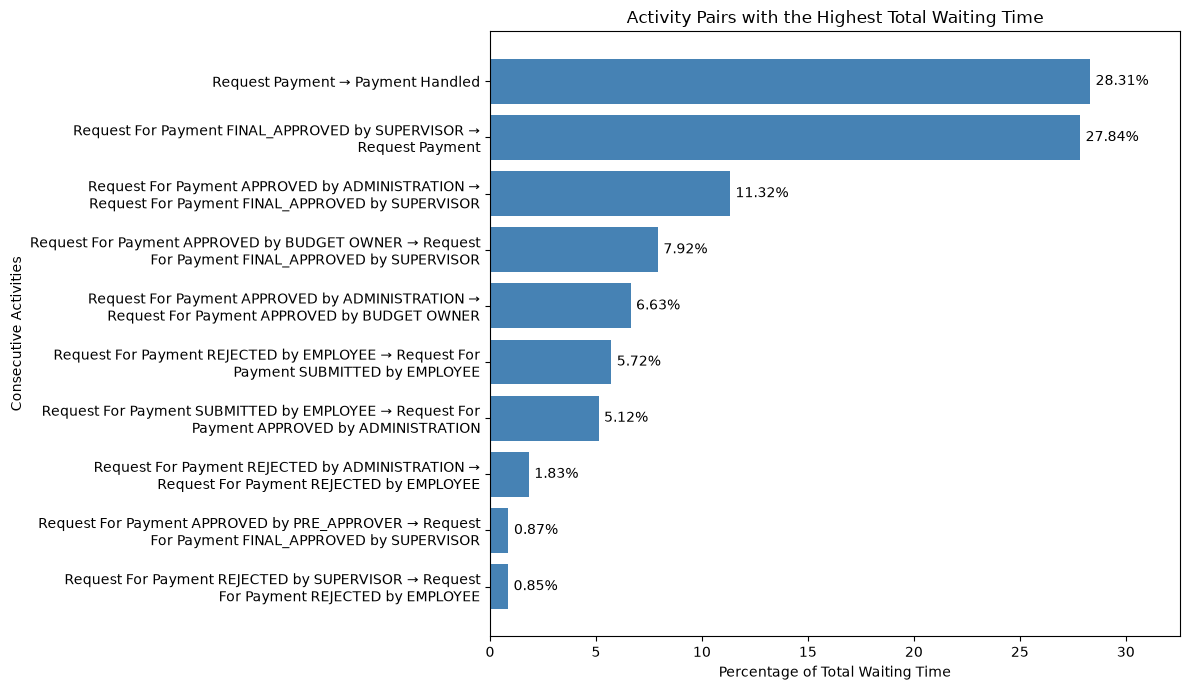

Chart saved in: D:\BPI-Challenge-2020\images\total_waiting_time_by_activity_pair.png


In [35]:
import textwrap

waiting_plot_data = (
    pair_total_waiting
    .head(10)
    .sort_values(
        by="percentage_of_total_waiting",
        ascending=True
    )
    .copy()
)

waiting_plot_data["activity_pair"] = (
    waiting_plot_data["previous_activity"]
    + " → "
    + waiting_plot_data["concept:name"]
)

wrapped_labels = [
    textwrap.fill(label, width=55)
    for label in waiting_plot_data["activity_pair"]
]

fig, ax = plt.subplots(
    figsize=(12, 7),
    facecolor="white"
)

bars = ax.barh(
    wrapped_labels,
    waiting_plot_data["percentage_of_total_waiting"],
    color="steelblue"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in waiting_plot_data[
            "percentage_of_total_waiting"
        ]
    ],
    padding=4
)

ax.set_title("Activity Pairs with the Highest Total Waiting Time")
ax.set_xlabel("Percentage of Total Waiting Time")
ax.set_ylabel("Consecutive Activities")
ax.set_xlim(
    0,
    waiting_plot_data["percentage_of_total_waiting"].max() * 1.15
)

plt.tight_layout()

output_path = images_directory / "total_waiting_time_by_activity_pair.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Chart saved in:", output_path.resolve())

## 24. Process Discovery: Directly-Follows Graph

Process discovery creates a process model directly from the recorded events.

We first construct a Directly-Follows Graph (DFG). Each node represents an activity, while an edge from activity A to activity B means that B directly followed A in at least one case.

The frequency of an edge shows how many times that direct passage was observed in the event log.

In [36]:
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

print("Number of directly-follows relations:", len(dfg))
print()
print("Start activities:")
print(start_activities)
print()
print("End activities:")
print(end_activities)

Number of directly-follows relations: 44

Start activities:
{'Request For Payment SUBMITTED by EMPLOYEE': 6814, 'Request For Payment SAVED by EMPLOYEE': 72}

End activities:
{'Payment Handled': 6305, 'Request For Payment REJECTED by MISSING': 41, 'Request For Payment REJECTED by EMPLOYEE': 448, 'Request For Payment FINAL_APPROVED by DIRECTOR': 1, 'Request For Payment SAVED by EMPLOYEE': 74, 'Request For Payment FINAL_APPROVED by SUPERVISOR': 11, 'Request For Payment REJECTED by ADMINISTRATION': 2, 'Request Payment': 2, 'Request For Payment FOR_APPROVAL by SUPERVISOR': 1, 'Request For Payment REJECTED by SUPERVISOR': 1}


In [37]:
dfg_table = pd.DataFrame(
    [
        {
            "source_activity": source,
            "target_activity": target,
            "frequency": frequency
        }
        for (source, target), frequency in dfg.items()
    ]
)

dfg_table = (
    dfg_table
    .sort_values(
        by="frequency",
        ascending=False
    )
    .reset_index(drop=True)
)

dfg_table.head(20)

,source_activity,target_activity,frequency
0,Request Payment,Payment Handled,6300
1,Request For Payment FINAL_APPROVED by SUPERVISOR,Request Payment,6261
2,Request For Payment SUBMITTED by EMPLOYEE,Request For Payment APPROVED by ADMINISTRATION,5489
3,Request For Payment APPROVED by ADMINISTRATION,Request For Payment FINAL_APPROVED by SUPERVISOR,3312
4,Request For Payment APPROVED by ADMINISTRATION,Request For Payment APPROVED by BUDGET OWNER,2014
5,Request For Payment APPROVED by BUDGET OWNER,Request For Payment FINAL_APPROVED by SUPERVISOR,1966
6,Request For Payment SUBMITTED by EMPLOYEE,Request For Payment REJECTED by ADMINISTRATION,836
7,Request For Payment REJECTED by ADMINISTRATION,Request For Payment REJECTED by EMPLOYEE,811
8,Request For Payment SUBMITTED by EMPLOYEE,Request For Payment FINAL_APPROVED by SUPERVISOR,656
9,Request For Payment REJECTED by EMPLOYEE,Request For Payment SUBMITTED by EMPLOYEE,635


In [38]:
dfg_image_path = images_directory / "directly_follows_graph_complete_log.png"

dfg_image_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

pm4py.save_vis_dfg(
    dfg,
    start_activities,
    end_activities,
    str(dfg_image_path)
)

print("DFG saved in:", dfg_image_path.resolve())

DFG saved in: D:\BPI-Challenge-2020\images\directly_follows_graph_complete_log.png


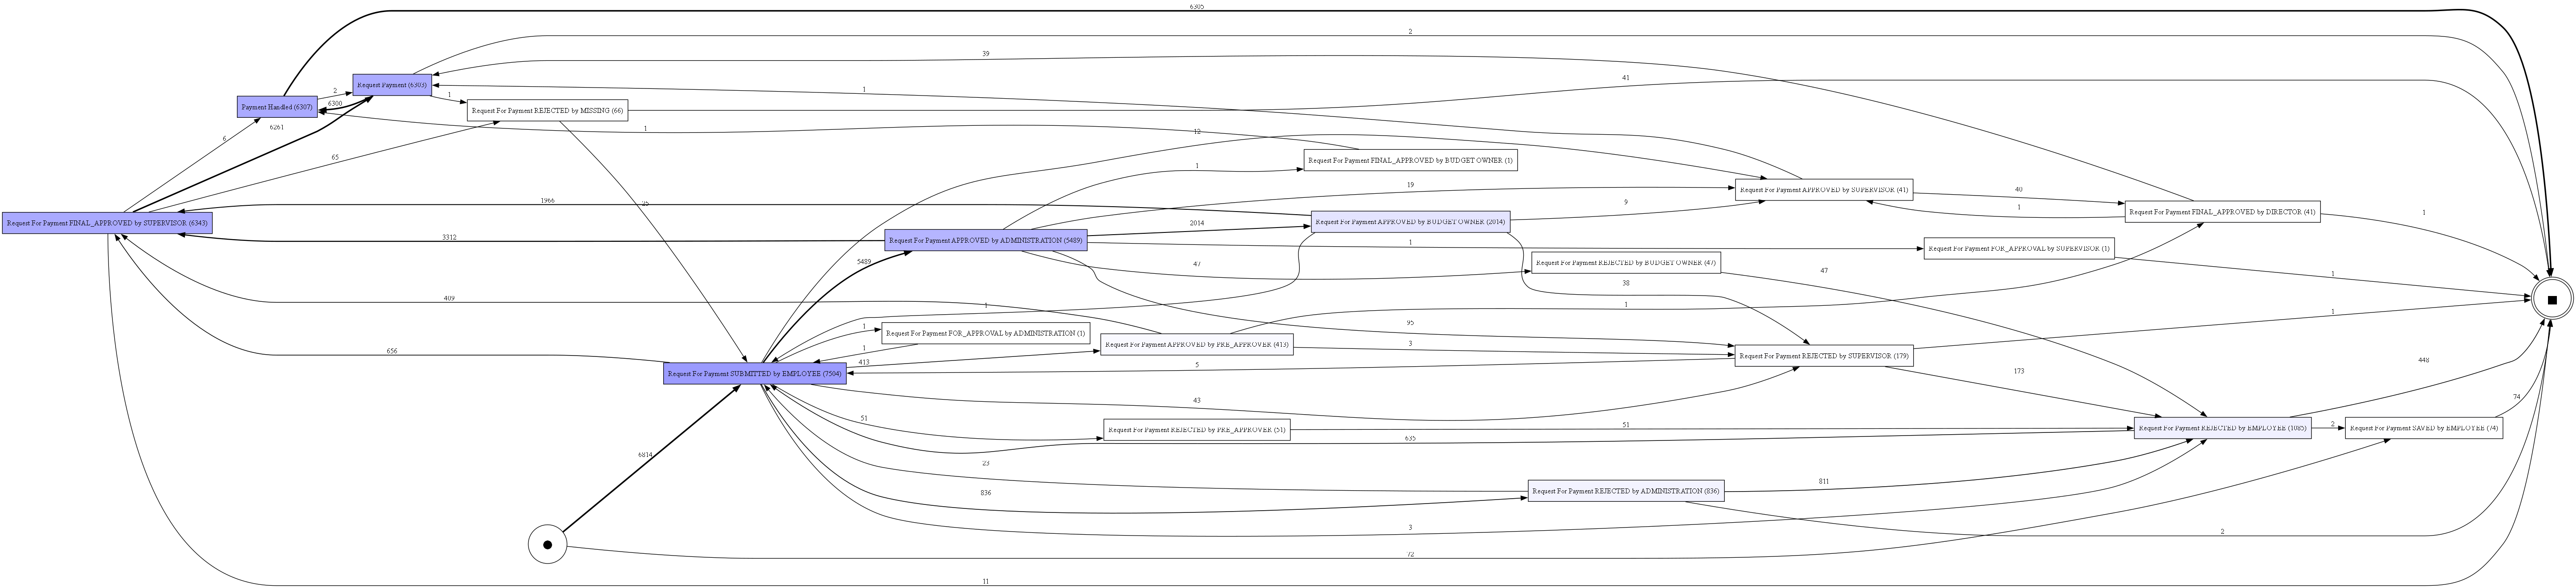

In [39]:
from IPython.display import Image, display

display(
    Image(filename=str(dfg_image_path))
)

### Interpretation of the Complete DFG

The event log contains 44 directly-follows relations.

Most cases start with a request submitted by an employee, while 72 cases start with a request saved as a draft. Most cases end with `Payment Handled`.

The most frequent process path passes through submission, administrative approval, final supervisor approval, payment request and payment handling. Some requests also require approval by the budget owner or a pre-approver.

The DFG also shows rejection and resubmission cycles. In particular, the transition from `REJECTED by EMPLOYEE` to `SUBMITTED by EMPLOYEE` occurs 635 times, providing evidence of rework.

The complete graph is difficult to read because it includes both frequent and rare behaviour. A filtered DFG is therefore created for visualization, while the complete event log remains unchanged.

In [40]:
minimum_edge_frequency = 100

filtered_dfg = {
    edge: frequency
    for edge, frequency in dfg.items()
    if frequency >= minimum_edge_frequency
}

visible_activities = set()

for source, target in filtered_dfg:
    visible_activities.add(source)
    visible_activities.add(target)

filtered_start_activities = {
    activity: frequency
    for activity, frequency in start_activities.items()
    if activity in visible_activities
}

filtered_end_activities = {
    activity: frequency
    for activity, frequency in end_activities.items()
    if activity in visible_activities
}

print(
    "Relations in the complete DFG:",
    len(dfg)
)

print(
    "Relations in the filtered DFG:",
    len(filtered_dfg)
)

Relations in the complete DFG: 44
Relations in the filtered DFG: 13


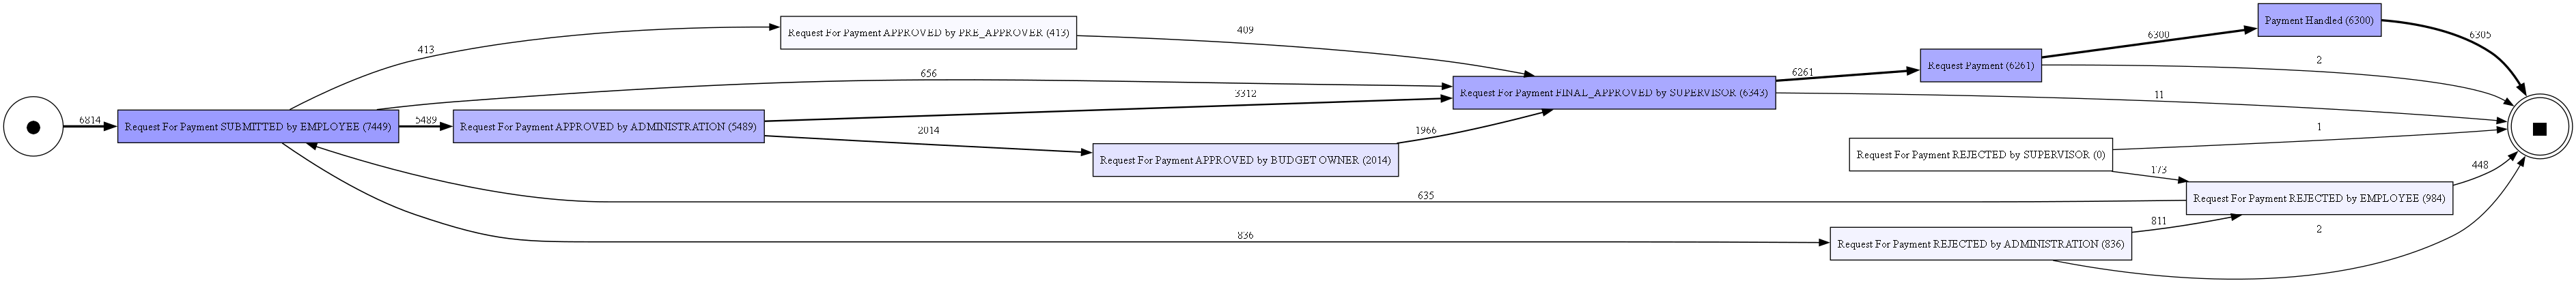

Filtered DFG saved in: D:\BPI-Challenge-2020\images\directly_follows_graph_filtered.png


In [41]:
filtered_dfg_path = images_directory / "directly_follows_graph_filtered.png"

pm4py.save_vis_dfg(
    filtered_dfg,
    filtered_start_activities,
    filtered_end_activities,
    str(filtered_dfg_path)
)

display(
    Image(filename=str(filtered_dfg_path))
)

print(
    "Filtered DFG saved in:",
    filtered_dfg_path.resolve()
)

### Filtered DFG

For readability, the filtered DFG shows only directly-follows relations occurring at least 100 times.

Rare relations are hidden from this visualization but are not removed from the original event log. The filtered graph is used only to present the dominant process behaviour more clearly.

## 25. Comparison of Process Discovery Algorithms

Three process discovery algorithms are applied to the same complete event log:

- Alpha Miner;
- Heuristics Miner;
- Inductive Miner.

Each algorithm produces a Petri net, but the algorithms use different approaches and may generate models with different levels of complexity and accuracy.

Using the same event log allows the resulting models to be compared fairly.

### Alpha Miner

Alpha Miner studies the order relationships between activities. It identifies activities that occur in sequence, in parallel or as alternatives.

It is mainly designed for structured and relatively clean event logs. Rare behaviour and short loops can make its model incomplete or inaccurate.

### Heuristics Miner

Heuristics Miner uses the frequency and strength of the relationships between activities.

It can reduce the influence of rare behaviour and noise, making it suitable for real event logs containing exceptions.

### Inductive Miner

Inductive Miner recursively divides the process into structures such as sequences, choices, parallel branches and loops.

It generally produces a structured Petri net that can always reach a valid final marking.

In [42]:
from time import perf_counter

models_directory = images_directory / "process_models"

models_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [43]:
alpha_start_time = perf_counter()

alpha_net, alpha_initial_marking, alpha_final_marking = (
    pm4py.discover_petri_net_alpha(log)
)

alpha_execution_time = (
    perf_counter() - alpha_start_time
)

alpha_statistics = {
    "algorithm": "Alpha Miner",
    "places": len(alpha_net.places),
    "visible_transitions": sum(
        transition.label is not None
        for transition in alpha_net.transitions
    ),
    "hidden_transitions": sum(
        transition.label is None
        for transition in alpha_net.transitions
    ),
    "arcs": len(alpha_net.arcs),
    "discovery_time_seconds": round(
        alpha_execution_time,
        2
    )
}

alpha_statistics

{'algorithm': 'Alpha Miner',
 'places': 19,
 'visible_transitions': 19,
 'hidden_transitions': 0,
 'arcs': 76,
 'discovery_time_seconds': 0.06}

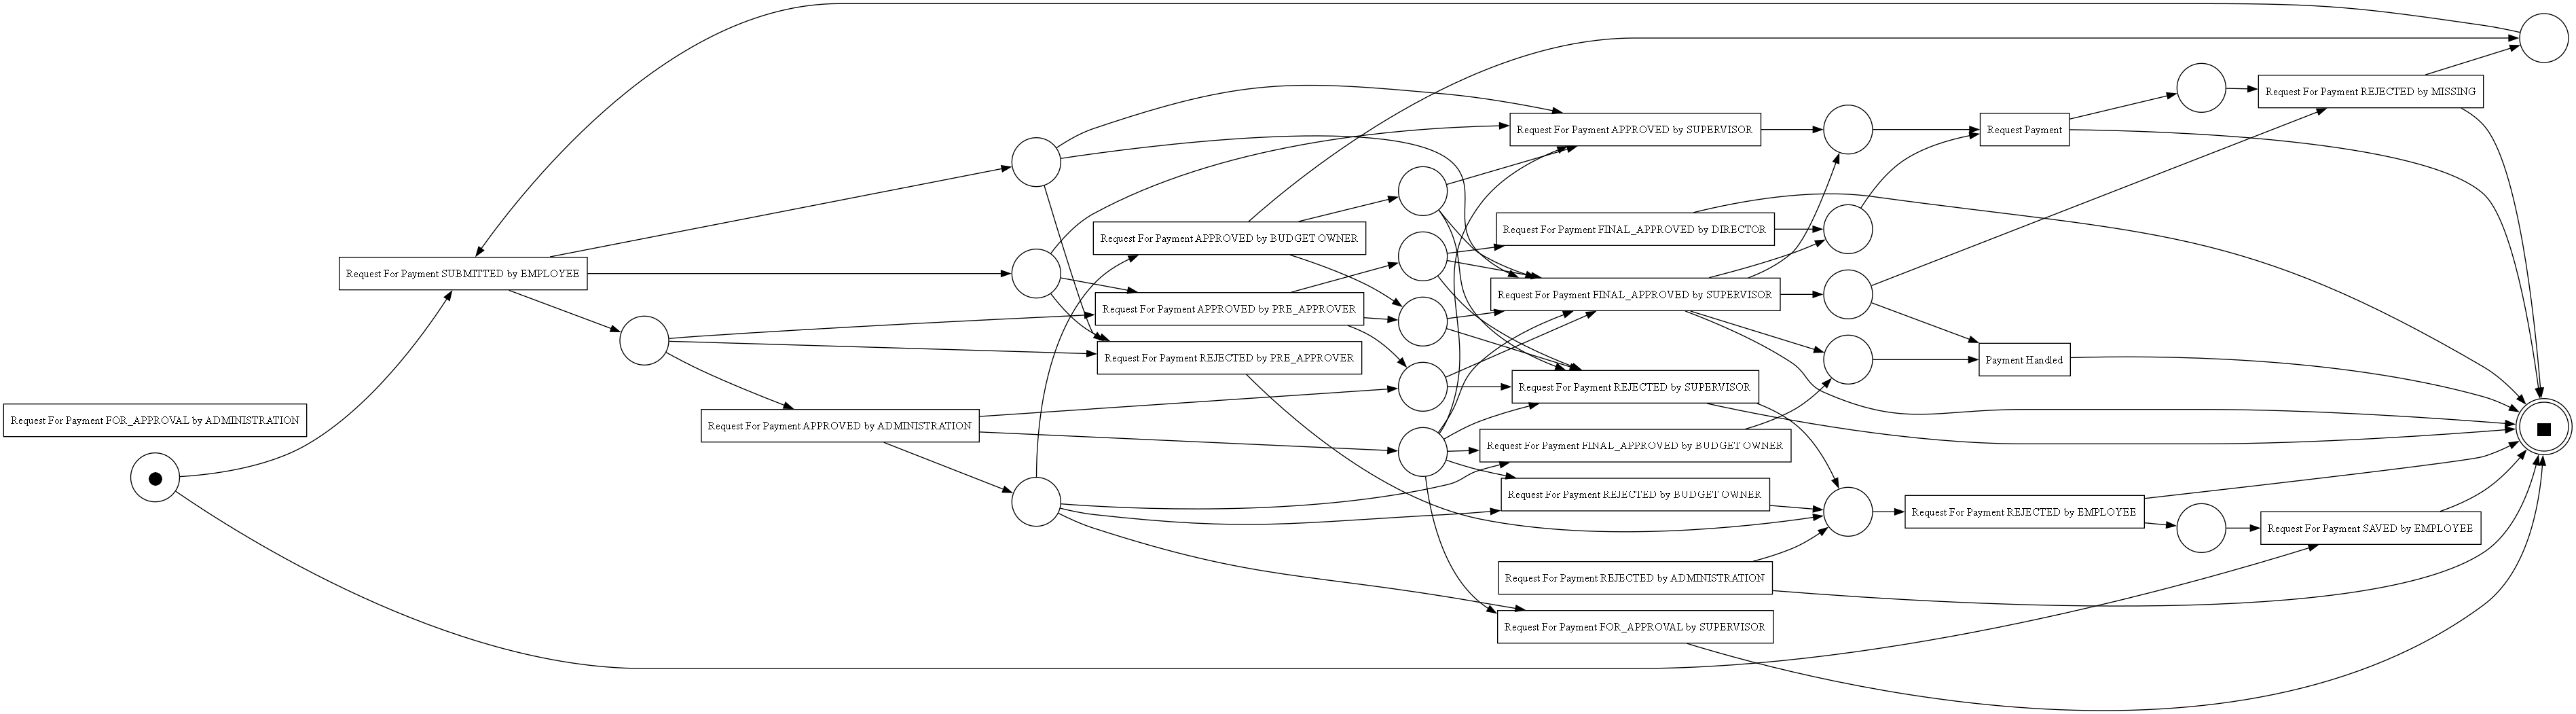

In [44]:
alpha_path = (
    models_directory
    / "alpha_miner_petri_net.png"
)

pm4py.save_vis_petri_net(
    alpha_net,
    alpha_initial_marking,
    alpha_final_marking,
    str(alpha_path)
)

display(
    Image(filename=str(alpha_path))
)

In [45]:
heuristics_start_time = perf_counter()

(
    heuristics_net,
    heuristics_initial_marking,
    heuristics_final_marking
) = pm4py.discover_petri_net_heuristics(log)

heuristics_execution_time = (
    perf_counter() - heuristics_start_time
)

heuristics_statistics = {
    "algorithm": "Heuristics Miner",
    "places": len(heuristics_net.places),
    "visible_transitions": sum(
        transition.label is not None
        for transition in heuristics_net.transitions
    ),
    "hidden_transitions": sum(
        transition.label is None
        for transition in heuristics_net.transitions
    ),
    "arcs": len(heuristics_net.arcs),
    "discovery_time_seconds": round(
        heuristics_execution_time,
        2
    )
}

heuristics_statistics

{'algorithm': 'Heuristics Miner',
 'places': 23,
 'visible_transitions': 19,
 'hidden_transitions': 25,
 'arcs': 93,
 'discovery_time_seconds': 0.13}

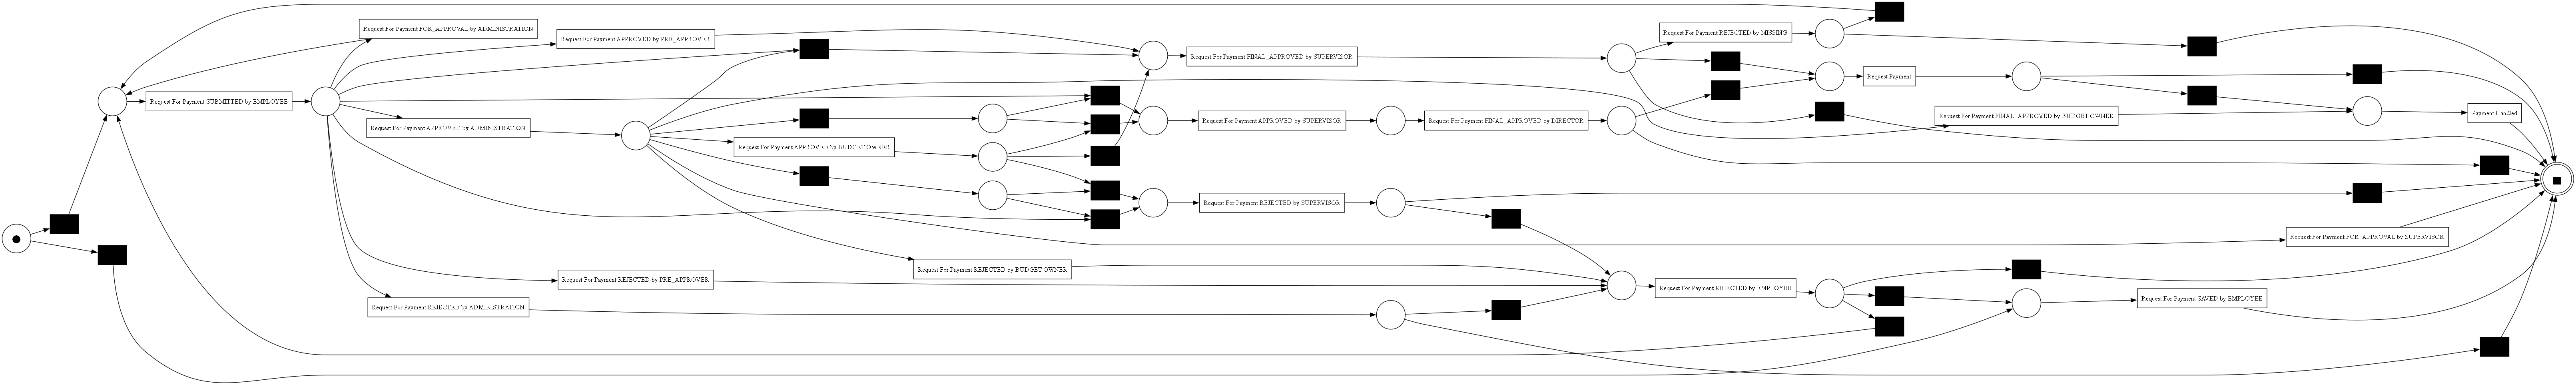

In [46]:
heuristics_path = (
    models_directory
    / "heuristics_miner_petri_net.png"
)

pm4py.save_vis_petri_net(
    heuristics_net,
    heuristics_initial_marking,
    heuristics_final_marking,
    str(heuristics_path)
)

display(
    Image(filename=str(heuristics_path))
)

In [47]:
inductive_start_time = perf_counter()

(
    inductive_net,
    inductive_initial_marking,
    inductive_final_marking
) = pm4py.discover_petri_net_inductive(
    log,
    noise_threshold=0.0,
    multi_processing=False
)

inductive_execution_time = (
    perf_counter() - inductive_start_time
)

inductive_statistics = {
    "algorithm": "Inductive Miner",
    "places": len(inductive_net.places),
    "visible_transitions": sum(
        transition.label is not None
        for transition in inductive_net.transitions
    ),
    "hidden_transitions": sum(
        transition.label is None
        for transition in inductive_net.transitions
    ),
    "arcs": len(inductive_net.arcs),
    "discovery_time_seconds": round(
        inductive_execution_time,
        2
    )
}

inductive_statistics

{'algorithm': 'Inductive Miner',
 'places': 33,
 'visible_transitions': 19,
 'hidden_transitions': 32,
 'arcs': 112,
 'discovery_time_seconds': 0.12}

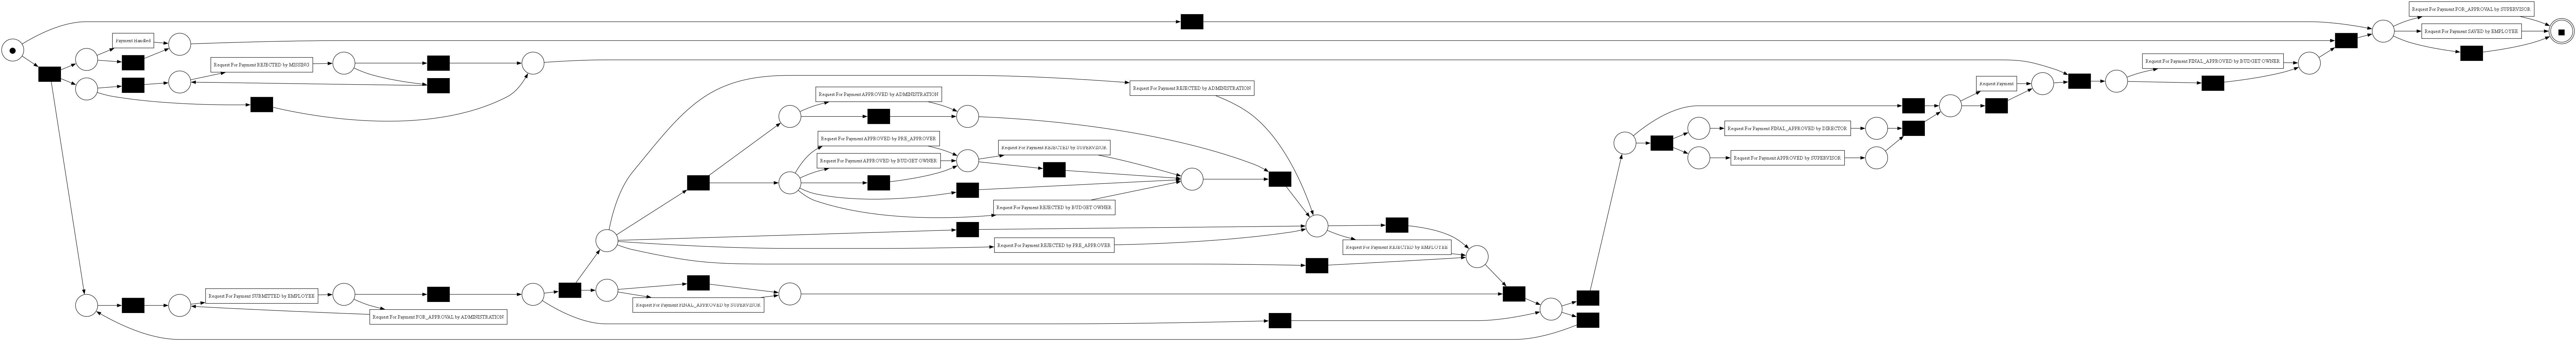

In [48]:
inductive_path = (
    models_directory
    / "inductive_miner_petri_net.png"
)

pm4py.save_vis_petri_net(
    inductive_net,
    inductive_initial_marking,
    inductive_final_marking,
    str(inductive_path)
)

display(
    Image(filename=str(inductive_path))
)

In [49]:
model_structure_comparison = pd.DataFrame(
    [
        alpha_statistics,
        heuristics_statistics,
        inductive_statistics
    ]
)

model_structure_comparison

,algorithm,places,visible_transitions,hidden_transitions,arcs,discovery_time_seconds
0,Alpha Miner,19,19,0,76,0.06
1,Heuristics Miner,23,19,25,93,0.13
2,Inductive Miner,33,19,32,112,0.12


### Structural Comparison of the Discovered Models

All three models contain 19 visible transitions, corresponding to the 19 activities recorded in the event log.

Alpha Miner produces the smallest model, with 19 places, 76 arcs and no hidden transitions.

Heuristics Miner produces a larger model containing 25 hidden transitions, while Inductive Miner produces the largest model, with 33 places, 32 hidden transitions and 112 arcs.

Hidden transitions do not represent recorded activities. They are routing elements used to model choices, skips and loops.

The structural comparison alone is insufficient to select the best model. The models must also be evaluated using fitness, precision, generalization and simplicity.

In [50]:
from pm4py.algo.evaluation.simplicity import (
    algorithm as simplicity_evaluator
)

def evaluate_model(
    model_name,
    event_log,
    petri_net,
    initial_marking,
    final_marking
):
    print("Evaluating:", model_name)

    start_time = perf_counter()

    fitness_result = pm4py.fitness_token_based_replay(
        event_log,
        petri_net,
        initial_marking,
        final_marking
    )

    precision = pm4py.precision_token_based_replay(
        event_log,
        petri_net,
        initial_marking,
        final_marking
    )

    generalization = pm4py.generalization_tbr(
        event_log,
        petri_net,
        initial_marking,
        final_marking
    )

    simplicity = simplicity_evaluator.apply(
        petri_net
    )

    evaluation_time = perf_counter() - start_time

    return {
        "algorithm": model_name,
        "fitness": fitness_result["log_fitness"],
        "fitting_traces_percentage": fitness_result[
            "percentage_of_fitting_traces"
        ],
        "precision": precision,
        "generalization": generalization,
        "simplicity": simplicity,
        "evaluation_time_seconds": evaluation_time
    }

In [51]:
alpha_quality = evaluate_model(
    "Alpha Miner",
    log,
    alpha_net,
    alpha_initial_marking,
    alpha_final_marking
)

heuristics_quality = evaluate_model(
    "Heuristics Miner",
    log,
    heuristics_net,
    heuristics_initial_marking,
    heuristics_final_marking
)

inductive_quality = evaluate_model(
    "Inductive Miner",
    log,
    inductive_net,
    inductive_initial_marking,
    inductive_final_marking
)

Evaluating: Alpha Miner


replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/257 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

Evaluating: Heuristics Miner


...

replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

Evaluating: Inductive Miner


replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/257 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/89 [00:00<?, ?it/s]

In [52]:
model_quality_comparison = pd.DataFrame(
    [
        alpha_quality,
        heuristics_quality,
        inductive_quality
    ]
)

numeric_columns = [
    "fitness",
    "fitting_traces_percentage",
    "precision",
    "generalization",
    "simplicity",
    "evaluation_time_seconds"
]

model_quality_comparison[numeric_columns] = (
    model_quality_comparison[numeric_columns]
    .round(4)
)

model_quality_comparison

,algorithm,fitness,fitting_traces_percentage,precision,generalization,simplicity,evaluation_time_seconds
0,Alpha Miner,0.6987,0.0000,0.0000,0.7836,0.3333,2.7300
1,Heuristics Miner,0.9376,40.3718,0.8083,0.6751,0.5630,2.7812
2,Inductive Miner,1.0000,100.0000,0.2934,0.8670,0.6000,3.3528


### Model Quality Comparison

Alpha Miner obtains a fitness of 0.6987, and none of the observed traces can be replayed perfectly. It is not suitable for the rejection cycles and exceptional behaviour contained in this event log.

Inductive Miner obtains perfect fitness and can replay 100% of the traces. However, its precision is only 0.2934. The model therefore allows many behaviours that were not observed in the log.

Heuristics Miner obtains a fitness of 0.9376 and a precision of 0.8083. Although only 40.37% of traces fit perfectly, most remaining traces require only limited corrections during token-based replay.

Heuristics Miner provides the best balance between representing the recorded behaviour, avoiding excessive additional behaviour and maintaining acceptable simplicity. It is therefore selected as the most suitable model for this analysis.

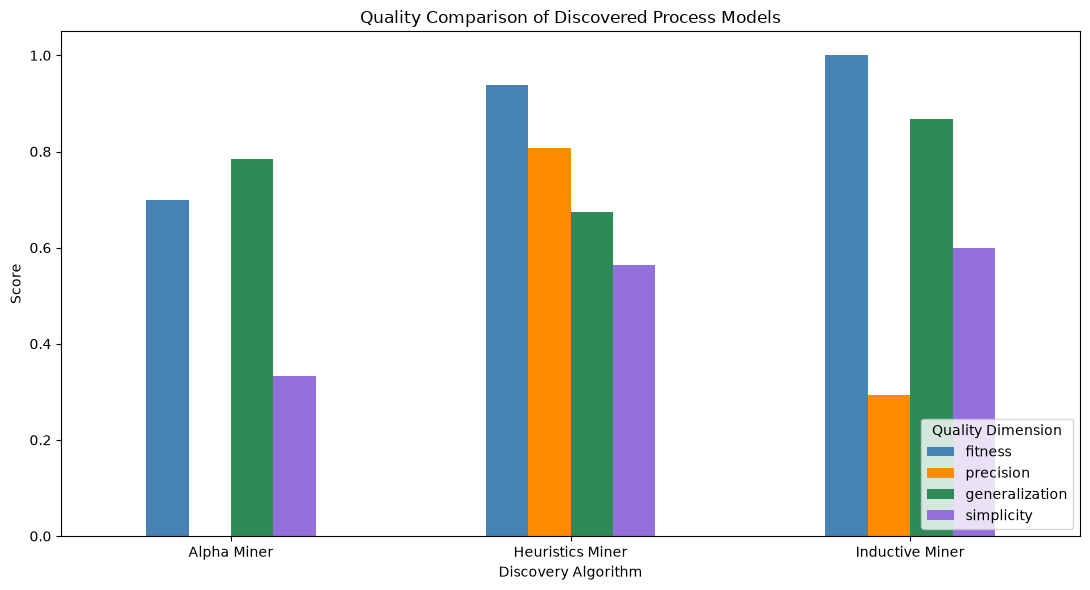

Chart saved in: D:\BPI-Challenge-2020\images\process_model_quality_comparison.png


In [53]:
quality_plot_data = (
    model_quality_comparison
    .set_index("algorithm")
    [
        [
            "fitness",
            "precision",
            "generalization",
            "simplicity"
        ]
    ]
)

ax = quality_plot_data.plot(
    kind="bar",
    figsize=(11, 6),
    color=[
        "steelblue",
        "darkorange",
        "seagreen",
        "mediumpurple"
    ]
)

ax.set_title("Quality Comparison of Discovered Process Models")
ax.set_xlabel("Discovery Algorithm")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Quality Dimension",
    loc="lower right"
)

plt.tight_layout()

model_comparison_path = images_directory / "process_model_quality_comparison.png"

plt.savefig(
    model_comparison_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "Chart saved in:",
    model_comparison_path.resolve()
)

## 26. Simplified Petri Net for Presentation

The process models discovered from the complete event log contain all 19
activities and several exceptional behaviours. Consequently, their graphical
representations are difficult to read in a short presentation.

For presentation purposes, an additional Petri net is discovered using the
two most frequent process variants. These variants cover 69.31% of all cases.

This simplified model is used only to visualise the dominant process behaviour.
The quantitative comparison of the mining algorithms remains based on the
complete event log.

In [54]:
# Select the two most frequent process variants
top_two_variants = set(
    variant_distribution.head(2)["variant"]
)

# Find the cases following these variants
top_two_case_ids = case_variants[
    case_variants.isin(top_two_variants)
].index

# Create the presentation subset
presentation_log = ordered_log[
    ordered_log[case_id_column].isin(top_two_case_ids)
].copy()

print("Cases in the simplified log:", presentation_log[case_id_column].nunique())
print(
    "Percentage of cases represented:",
    round(
        presentation_log[case_id_column].nunique()
        / number_of_cases
        * 100,
        2
    ),
    "%"
)

Cases in the simplified log: 4773
Percentage of cases represented: 69.31 %


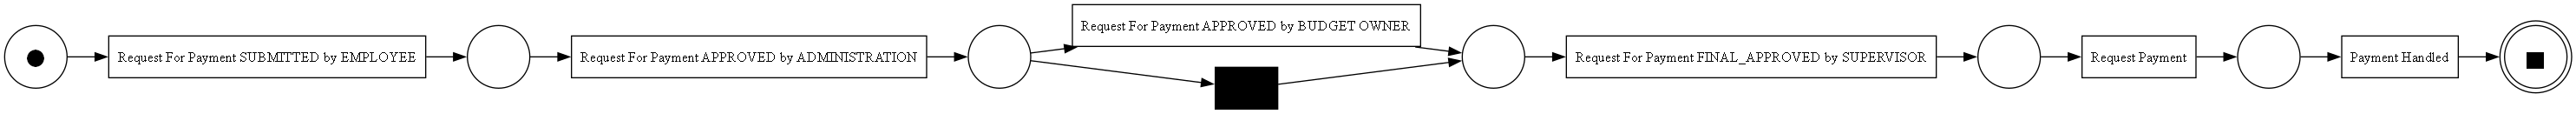

In [55]:
simplified_net, simplified_im, simplified_fm = (
    pm4py.discover_petri_net_heuristics(presentation_log)
)

pm4py.view_petri_net(
    simplified_net,
    simplified_im,
    simplified_fm
)

In [56]:
simplified_net_path = images_directory / "simplified_heuristics_petri_net.png"

pm4py.save_vis_petri_net(
    simplified_net,
    simplified_im,
    simplified_fm,
    str(simplified_net_path)
)

print("Petri net saved in:", simplified_net_path)

Petri net saved in: D:\BPI-Challenge-2020\images\simplified_heuristics_petri_net.png


## 27. LLM-Assisted Analysis

A Large Language Model is used to support the interpretation of the process mining results.

The complete event log is not sent to the model. Instead, the model receives a compact summary containing the main statistics calculated with PM4Py and pandas. This reduces the amount of data transmitted and limits the cost of the API request.

The LLM is asked to:

- identify possible imbalances in the process;
- interpret unusual or incomplete cases;
- identify the main waiting-time bottlenecks;
- suggest possible process improvements;
- compare the discovered process models.

The LLM does not replace the numerical analysis. Its conclusions must be checked against the values calculated in the notebook.

### Conversation memory and local transcript

Follow-up requests use `previous_response_id`, which connects each new response to the preceding one and allows the model to use the earlier conversational context. The notebook also appends the initial request, the initial answer and every subsequent question-answer pair to `results/llm_conversation_history.txt`. This local transcript remains available independently of the active notebook kernel.

In [57]:
from getpass import getpass
from openai import OpenAI

api_key = getpass("Paste the OpenAI API key: ").strip()

if not api_key.startswith("sk-"):
    raise ValueError(
        "The inserted value is not an API key. "
        "Paste the content beginning with 'sk-', not the file name."
    )

client = OpenAI(api_key=api_key)

# Remove the additional variable after creating the client
del api_key

print("OpenAI client configured.")

OpenAI client configured.


In [58]:
llm_outcomes = outcome_distribution.to_string(index=False)

llm_waiting_pairs = (
    pair_total_waiting
    .head(5)
    .merge(
        activity_pair_waiting_times,
        on=["previous_activity", "concept:name"],
        how="left"
    )[
        [
            "previous_activity",
            "concept:name",
            "number_of_occurrences",
            "median_waiting_days",
            "percentage_of_total_waiting"
        ]
    ]
    .to_string(index=False)
)

llm_model_quality = model_quality_comparison[
    [
        "algorithm",
        "fitness",
        "fitting_traces_percentage",
        "precision",
        "generalization",
        "simplicity"
    ]
].to_string(index=False)

top_two_case_count = int(
    variant_distribution.head(2)["number_of_cases"].sum()
)
top_ten_case_count = int(
    variant_distribution.head(10)["number_of_cases"].sum()
)

llm_input_summary = f"""
DATASET
- Dataset: BPI Challenge 2020 - Request for Payment
- Number of cases: {number_of_cases:,}
- Number of events: {number_of_events:,}
- Number of activities: {log["concept:name"].nunique()}
- Number of process variants: {number_of_variants}

DATA QUALITY
- Missing case identifiers: {log[case_id_column].isna().sum()}
- Missing activity names: {log["concept:name"].isna().sum()}
- Missing timestamps: {log[timestamp_column].isna().sum()}
- Exact duplicated rows: {log.duplicated().sum()}
- Cases containing one event: {(events_per_case == 1).sum()}

CASE OUTCOMES
{llm_outcomes}

TRACE AND VARIANT DISTRIBUTION
- Minimum trace length: {events_per_case.min()} event(s)
- Maximum trace length: {events_per_case.max()} events
- Average trace length: {events_per_case.mean():.2f} events
- Median trace length: {events_per_case.median():.0f} events
- Two most frequent variants: {top_two_case_count} cases ({top_two_case_count / number_of_cases * 100:.2f}%)
- Ten most frequent variants: {top_ten_case_count} cases ({top_ten_case_count / number_of_cases * 100:.2f}%)
- Variants followed by at most five cases: {rare_variants}
- Cases belonging to those rare variants: {cases_in_rare_variants} ({cases_in_rare_variants / number_of_cases * 100:.2f}%)

DURATION OF COMPLETED CASES
- Mean duration: {completed_case_times["duration_days"].mean():.2f} days
- Median duration: {completed_case_times["duration_days"].median():.2f} days
- 90th percentile: {completed_case_times["duration_days"].quantile(0.90):.2f} days
- 95th percentile: {completed_case_times["duration_days"].quantile(0.95):.2f} days
- 99th percentile: {completed_case_times["duration_days"].quantile(0.99):.2f} days
- Maximum duration: {completed_case_times["duration_days"].max():.2f} days
- Cases lasting more than 30 days: {(completed_case_times["duration_days"] > 30).sum()}
- Cases lasting more than 70 days: {(completed_case_times["duration_days"] > 70).sum()}

MAIN WAITING-TIME PAIRS
{llm_waiting_pairs}

DISCOVERED PROCESS MODELS
{llm_model_quality}
"""

print(llm_input_summary)


DATASET
- Dataset: BPI Challenge 2020 - Request for Payment
- Number of cases: 6,886
- Number of events: 36,796
- Number of activities: 19
- Number of process variants: 89

DATA QUALITY
- Missing case identifiers: 0
- Missing activity names: 0
- Missing timestamps: 0
- Exact duplicated rows: 0
- Cases containing one event: 72

CASE OUTCOMES
            outcome  number_of_cases  percentage_of_cases
          Completed             6305                91.56
           Rejected              492                 7.14
              Saved               74                 1.07
Incomplete or other               15                 0.22

TRACE AND VARIANT DISTRIBUTION
- Minimum trace length: 1 event(s)
- Maximum trace length: 20 events
- Average trace length: 5.34 events
- Median trace length: 5 events
- Two most frequent variants: 4773 cases (69.31%)
- Ten most frequent variants: 6495 cases (94.32%)
- Variants followed by at most five cases: 57
- Cases belonging to those rare variants: 82 (1.19%

In [59]:
llm_prompt = f"""
You are assisting with a university process mining project.

The following summary was calculated from the BPI Challenge 2020
Request for Payment event log using pandas and PM4Py.

{llm_input_summary}

Using only the supplied results, answer these questions:

1. Is the observed process imbalanced?
   Consider separately:
   - case outcomes;
   - process variants;
   - case durations;
   - waiting-time distribution.

2. Which results appear unusual or worthy of further investigation?
   Explain why using the numerical evidence.

3. Where are the main process bottlenecks?
   Distinguish between:
   - a frequently occurring delay;
   - an exceptionally long individual delay;
   - a transition responsible for a large percentage of total waiting time.

4. Compare Alpha Miner, Heuristics Miner and Inductive Miner using
   fitness, precision, generalization and simplicity.
   Explain the trade-offs and recommend the most suitable model
   for presenting the observed process.

5. Suggest a maximum of four possible process improvements.
   Connect every suggestion to a specific result from the analysis.

Present the final answer using this table:

| Finding | Numerical evidence | Possible interpretation | Suggested action |

After the table, add:
- a short recommendation about the process model;
- a short limitations paragraph.

Important rules:
- Do not invent information that is not contained in the summary.
- Clearly distinguish facts from hypotheses.
- A rare activity is not automatically an error.
- A long duration is not automatically caused by inefficiency.
- Do not claim that the recommendations have already been validated.
- Use simple language.
- Select at most five important findings.
- Avoid repeating the same numerical evidence.
- Keep the response below 450 words.
"""

**NOTE:** The following part consumes credit.

In [60]:
llm_analysis = None

response = client.responses.create(
    model="gpt-5-mini",
    input=llm_prompt,
    reasoning={"effort": "low"},
    max_output_tokens=4000,
    store=True
)

print("Response status:", response.status)
print("Incomplete details:", response.incomplete_details)
print("Token usage:", response.usage)

if response.status == "completed":
    llm_analysis = response.output_text
    print("\nLLM analysis:\n")
    print(llm_analysis)
else:
    print("\nThe response was incomplete and will not be used as the initial analysis.")
    print("\nPartial response:\n")
    print(response.output_text)

Response status: completed
Incomplete details: None
Token usage: ResponseUsage(input_tokens=1028, input_tokens_details=InputTokensDetails(cache_write_tokens=0, cached_tokens=0), output_tokens=1118, output_tokens_details=OutputTokensDetails(reasoning_tokens=320), total_tokens=2146)

LLM analysis:

| Finding | Numerical evidence | Possible interpretation (fact vs hypothesis) | Suggested action |
|---|---:|---|---|
| 1. Outcome imbalance: most cases complete | Completed: 6,305 cases (91.56%); Rejected 7.14%; Saved 1.07%; Incomplete/other 0.22% | Fact: outcomes are strongly skewed toward "Completed". Hypothesis: few rework or rejection processes dominate; some small subgroup needs attention. | Focus quality checks on the ~8.4% non-completed cases (Rejected/Saved/Other). Run a root-cause analysis on rejected cases before making wider process changes. |
| 2. Variant imbalance: single dominant variant | Two most frequent variants: 4,773 cases (69.31%); top 10 variants: 6,495 cases (94.32%); 5

In [61]:
print("Response status:", response.status)
print("Incomplete details:", response.incomplete_details)

Response status: completed
Incomplete details: None


In [62]:
from datetime import datetime

if llm_analysis is None:
    raise RuntimeError(
        "The initial LLM response was incomplete, so the conversation was not started."
    )

llm_output_path = results_directory / "llm_assisted_analysis.txt"
conversation_output_path = results_directory / "llm_conversation_history.txt"
results_directory.mkdir(parents=True, exist_ok=True)

llm_output_path.write_text(llm_analysis, encoding="utf-8")

session_time = datetime.now().astimezone().isoformat(timespec="seconds")
with conversation_output_path.open("a", encoding="utf-8") as transcript:
    transcript.write("\n" + "=" * 80 + "\n")
    transcript.write(f"NEW LLM SESSION - {session_time}\n")
    transcript.write("=" * 80 + "\n\n")
    transcript.write("INITIAL USER REQUEST\n")
    transcript.write(llm_prompt.strip() + "\n\n")
    transcript.write("INITIAL LLM RESPONSE\n")
    transcript.write(llm_analysis.strip() + "\n\n")

print("Complete LLM analysis saved in:", llm_output_path)
print("Conversation transcript initialized in:", conversation_output_path)

Complete LLM analysis saved in: D:\BPI-Challenge-2020\results\llm_assisted_analysis.txt
Conversation transcript initialized in: D:\BPI-Challenge-2020\results\llm_conversation_history.txt


In [63]:
current_response = response

assistant_introduction = (
    "Ciao! Sono l'assistente per l'analisi del processo Request for Payment. "
    "Posso aiutarti a comprendere risultati, varianti, tempi di attesa, "
    "Petri net e metriche dei modelli, oppure a discutere possibili miglioramenti. "
    "Le mie risposte si basano sui risultati calcolati nel notebook e le eventuali "
    "cause che propongo devono essere considerate ipotesi. Cosa posso fare per te?"
)

print("\nLLM:")
print(assistant_introduction)
print("\nPuoi fare più domande. Scrivi 'exit' per terminare.")

introduction_time = datetime.now().astimezone().isoformat(timespec="seconds")
with conversation_output_path.open("a", encoding="utf-8") as transcript:
    transcript.write(f"[{introduction_time}] LLM INTRODUCTION\n")
    transcript.write(assistant_introduction + "\n\n")

while True:
    question = input("\nYou: " ).strip()

    if question.lower() in {"exit", "quit", "stop"}:
        print("Conversation closed.")
        break

    if not question:
        print("Please enter a question or type 'exit'.")
        continue

    try:
        followup_response = client.responses.create(
            model="gpt-5-mini",
            previous_response_id=current_response.id,
            input=(
                question
                + "\nAnswer simply, distinguish facts from hypotheses, "
                + "and use no more than 250 words."
            ),
            reasoning={"effort": "low"},
            max_output_tokens=2500,
            store=True
        )

        answer = followup_response.output_text.strip()
        turn_time = datetime.now().astimezone().isoformat(timespec="seconds")

        print("\nStatus:", followup_response.status)
        print("\nLLM:")
        print(answer)

        with conversation_output_path.open("a", encoding="utf-8") as transcript:
            transcript.write(f"[{turn_time}] YOU\n{question}\n\n")
            transcript.write(
                f"[{turn_time}] LLM - status: {followup_response.status}\n"
            )
            transcript.write((answer or "[No text returned]") + "\n\n")

        if followup_response.status == "completed":
            current_response = followup_response
            response = followup_response
        else:
            print("The partial response was saved, but it was not added to the conversation chain.")

        print("Conversation updated in:", conversation_output_path)

    except Exception as error:
        error_time = datetime.now().astimezone().isoformat(timespec="seconds")
        with conversation_output_path.open("a", encoding="utf-8") as transcript:
            transcript.write(f"[{error_time}] YOU\n{question}\n\n")
            transcript.write(f"[{error_time}] API ERROR\n{error}\n\n")
        print("API error:", error)
        print("The error was saved. You can try another question or type 'exit'.")


LLM:
Ciao! Sono l'assistente per l'analisi del processo Request for Payment. Posso aiutarti a comprendere risultati, varianti, tempi di attesa, Petri net e metriche dei modelli, oppure a discutere possibili miglioramenti. Le mie risposte si basano sui risultati calcolati nel notebook e le eventuali cause che propongo devono essere considerate ipotesi. Cosa posso fare per te?

Puoi fare più domande. Scrivi 'exit' per terminare.

Status: completed

LLM:
Ciao! Ecco una risposta semplice e breve.

Fatti:
- Esiti molto sbilanciati: 91.56% casi Completed, 7.14% Rejected, 1.07% Saved, 0.22% altri.  
- Varianti concentrate: le 2 varianti più frequenti coprono 69.31%; le prime 10 coprono 94.32%; 57 varianti rare riguardano solo 82 casi (1.19%).  
- Durate con coda lunga: media 12.54 giorni, mediana 9.04; massimo 405.99 giorni; 356 casi >30 giorni; 64 casi >70 giorni.  
- Grandi attese concentrate su due transizioni: "Request Payment" → "Payment Handled" (6.300 occ., median 3.23 giorni, 28.31% 